# Karachi Air Quality Index Forecasting System Using Machine Learning and Deep Learning

**Objective:** Predict Karachi's Air Quality Index for the next 3 days, hour by hour (72 hourly predictions: Day 1 = hours 1-24, Day 2 = hours 25-48, Day 3 = hours 49-72).

**Location:** Karachi, Pakistan 

**Data source:** [Open-Meteo](https://open-meteo.com) Historical Weather API + Air Quality API
---


## Notebook sections
1. Introduction  
2. Imports & Configuration  
3. Install Dependencies  
4. Data Collection
5. Data Exploration  
6. Data Quality Analysis  
7. Preprocessing  
8. Feature Engineering
9. Target Construction  **-> Feast Feature Store Setup / Register / Materialize / Retrieve Historical Features ->**
10. Train/Val/Test Split (now sourced from Feast)  
11. Baseline Models  
12. ML Models
13. Ridge Regression  
14. Deep Learning (LSTM)  
15. Hyperparameter Optimization
16. Ensemble Modeling  
17. Model Evaluation  
18. Error Analysis  
19. Feature Importance
20. Final Model Selection  
21. 72-Hour Recursive Forecast  
22. AQI Categories
23. Forecast Visualization  
24. Save Model & Outputs (+ Feast-aware model_metadata.json)
**-> Feast Feature Store Validation (online retrieval + schema check + demonstration) ->**
25. Dashboard (Feast online retrieval)  
26. Final Results  
27. Conclusions


## 3. Install Dependencies


In [1]:
import importlib, subprocess, sys

REQUIRED = [
    "pandas", "numpy", "requests", "scikit-learn", "matplotlib", "seaborn",
    "plotly", "joblib", "openpyxl", "lightgbm", "xgboost", "catboost",
    "tensorflow", "streamlit", "folium", "shap", "optuna", "requests_cache", "retry_requests",
    "feast", "streamlit_folium", "duckdb", "ibis-framework", "pyarrow_hotfix",
]

IMPORT_NAME_OVERRIDES = {
    "scikit-learn": "sklearn",
    "requests_cache": "requests_cache",
    "retry_requests": "retry_requests",
    "streamlit_folium": "streamlit_folium",
    "ibis-framework": "ibis",
    "pyarrow_hotfix": "pyarrow_hotfix",
}

def ensure(pkg):
    mod_name = IMPORT_NAME_OVERRIDES.get(pkg, pkg)
    try:
        importlib.import_module(mod_name)
        return True
    except ImportError:
        print(f"Installing {pkg} ...")
        for extra_args in ([], ["--break-system-packages"]):
            try:
                subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg] + extra_args)
                importlib.import_module(mod_name)
                return True
            except subprocess.CalledProcessError:
                continue
            except ImportError:
                continue
        print(f"  -> Could not install {pkg}. Notebook will fall back where possible.")
        return False

AVAILABILITY = {pkg: ensure(pkg) for pkg in REQUIRED}
print("\\nPackage availability summary:")
for k, v in AVAILABILITY.items():
    print(f"  {k:20s} : {'OK' if v else 'MISSING (fallback will be used)'}")


2026-09-02 11:27:28.872 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


\nPackage availability summary:
  pandas               : OK
  numpy                : OK
  requests             : OK
  scikit-learn         : OK
  matplotlib           : OK
  seaborn              : OK
  plotly               : OK
  joblib               : OK
  openpyxl             : OK
  lightgbm             : OK
  xgboost              : OK
  catboost             : OK
  tensorflow           : OK
  streamlit            : OK
  folium               : OK
  shap                 : OK
  optuna               : OK
  requests_cache       : OK
  retry_requests       : OK
  feast                : OK
  streamlit_folium     : OK
  duckdb               : OK
  ibis-framework       : OK
  pyarrow_hotfix       : OK


## 2. Imports and Configuration


In [2]:
import os
import sys
import time
import json
import math
import warnings
import pickle as pkl
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import requests

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, median_absolute_error, explained_variance_score

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
sns.set_style("whitegrid")

try:
    import lightgbm as lgb
    HAS_LIGHTGBM = True
except ImportError:
    HAS_LIGHTGBM = False

try:
    import xgboost as xgb
    HAS_XGBOOST = True
except ImportError:
    HAS_XGBOOST = False

try:
    import catboost as cb
    HAS_CATBOOST = True
except ImportError:
    HAS_CATBOOST = False

try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    HAS_TENSORFLOW = True
    tf.random.set_seed(42)
except ImportError:
    HAS_TENSORFLOW = False

try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    HAS_OPTUNA = True
except ImportError:
    HAS_OPTUNA = False

try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False

np.random.seed(42)

print("LightGBM:", HAS_LIGHTGBM, "| XGBoost:", HAS_XGBOOST, "| CatBoost:", HAS_CATBOOST,
      "| TensorFlow:", HAS_TENSORFLOW, "| Optuna:", HAS_OPTUNA, "| SHAP:", HAS_SHAP)


LightGBM: True | XGBoost: True | CatBoost: True | TensorFlow: True | Optuna: True | SHAP: True


In [3]:
PROJECT_ROOT = os.getcwd() if os.path.basename(os.getcwd()) != "notebooks" else os.path.dirname(os.getcwd())
DATA_RAW_DIR = os.path.join(PROJECT_ROOT, "data", "raw")
DATA_PROCESSED_DIR = os.path.join(PROJECT_ROOT, "data", "processed")
MODELS_DIR = os.path.join(PROJECT_ROOT, "models")
OUTPUTS_DIR = os.path.join(PROJECT_ROOT, "outputs")
FIGURES_DIR = os.path.join(OUTPUTS_DIR, "figures")
PREDICTIONS_DIR = os.path.join(OUTPUTS_DIR, "predictions")
METRICS_DIR = os.path.join(OUTPUTS_DIR, "metrics")

for d in [DATA_RAW_DIR, DATA_PROCESSED_DIR, MODELS_DIR, FIGURES_DIR, PREDICTIONS_DIR, METRICS_DIR]:
    os.makedirs(d, exist_ok=True)

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from data_pipeline import LATITUDE, LONGITUDE, TIMEZONE, CITY_NAME


START_DATE = "2022-09-01"
END_DATE = "2026-08-12"        


FORECAST_HOURS = 72              


FAST_MODE = True                 
FORCE_DOWNLOAD = False           


AQI_STANDARD = "US EPA AQI (0-500 scale)"  
                                             
                                                                                    

print(f"Project root      : {PROJECT_ROOT}")
print(f"Location           : {CITY_NAME} ({LATITUDE}, {LONGITUDE})")
print(f"Historical window  : {START_DATE} -> {END_DATE}")
print(f"Forecast horizon   : {FORECAST_HOURS} hours")
print(f"FAST_MODE          : {FAST_MODE}")
print(f"AQI standard       : {AQI_STANDARD}")


Project root      : c:\Users\Asad\Desktop\Karachi AQI Project\karachi-aqi-forecasting\karachi-aqi-forecasting
Location           : Karachi (24.8607, 67.0011)
Historical window  : 2022-09-01 -> 2026-08-12
Forecast horizon   : 72 hours
FAST_MODE          : True
AQI standard       : US EPA AQI (0-500 scale)


## 4. Data Collection

We pull two hourly datasets from Open-Meteo's free APIs:

- **Historical Weather API** (`archive-api.open-meteo.com`) — temperature, humidity, dew point, precipitation, pressure, wind, cloud cover, radiation, etc.
- **Air Quality API** (`air-quality-api.open-meteo.com`) — PM2.5, PM10, CO, NO2, SO2, O3, NH3, and Open-Meteo's own pre-computed `us_aqi`.


In [4]:
from data_pipeline import (
    WEATHER_ARCHIVE_URL, AIR_QUALITY_ARCHIVE_URL, WEATHER_FORECAST_URL, AIR_QUALITY_FORECAST_URL,
    fetch_weather_data as _fetch_weather_data,
    fetch_air_quality_data as _fetch_air_quality_data,
    fetch_weather_forecast, fetch_air_quality_recent,
)
from feature_engineering import WEATHER_HOURLY_VARS, AIR_QUALITY_HOURLY_VARS

def fetch_weather_data(start_date=START_DATE, end_date=END_DATE, force_download=FORCE_DOWNLOAD):
    return _fetch_weather_data(start_date, end_date, force_download, data_raw_dir=DATA_RAW_DIR)

def fetch_air_quality_data(start_date=START_DATE, end_date=END_DATE, force_download=FORCE_DOWNLOAD):
    return _fetch_air_quality_data(start_date, end_date, force_download, data_raw_dir=DATA_RAW_DIR)

print("Imported data-collection functions from data_pipeline.py")


Imported data-collection functions from data_pipeline.py


In [5]:
weather_df = fetch_weather_data()
air_quality_df = fetch_air_quality_data()

print("\\nWeather data shape      :", weather_df.shape)
print("Air quality data shape  :", air_quality_df.shape)
weather_df.head()


Loading cached weather data: c:\Users\Asad\Desktop\Karachi AQI Project\karachi-aqi-forecasting\karachi-aqi-forecasting\data\raw\weather_2022-09-01_2026-08-12.csv
Loading cached air quality data: c:\Users\Asad\Desktop\Karachi AQI Project\karachi-aqi-forecasting\karachi-aqi-forecasting\data\raw\air_quality_2022-09-01_2026-08-12.csv
\nWeather data shape      : (34608, 16)
Air quality data shape  : (34608, 15)


,time,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,rain,cloud_cover,surface_pressure,pressure_msl,wind_speed_10m,wind_direction_10m,wind_gusts_10m,shortwave_radiation,direct_radiation,diffuse_radiation
0,2022-09-01 00:00:00,26.8,88,24.5,30.6,0.0,0.0,43,1006.5,1007.3,17.7,258,24.1,0.0,0.0,0.0
1,2022-09-01 01:00:00,26.8,87,24.4,30.6,0.0,0.0,35,1006.2,1007.0,17.5,262,24.5,0.0,0.0,0.0
2,2022-09-01 02:00:00,26.8,86,24.2,30.3,0.0,0.0,14,1005.4,1006.2,18.1,264,24.8,0.0,0.0,0.0
3,2022-09-01 03:00:00,26.5,87,24.2,29.8,0.0,0.0,28,1005.0,1005.8,20.2,269,27.7,0.0,0.0,0.0
4,2022-09-01 04:00:00,26.5,87,24.3,29.8,0.0,0.0,37,1005.0,1005.8,20.6,266,28.4,0.0,0.0,0.0


In [6]:
air_quality_df.head()

,time,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,ammonia,us_aqi,us_aqi_pm2_5,us_aqi_pm10,us_aqi_no2,us_aqi_co,us_aqi_so2,us_aqi_ozone
0,2022-09-01 00:00:00,29.4,15.1,320.0,16.9,14.5,35.0,NaN,72,72,37,8,4,8,25.0
1,2022-09-01 01:00:00,29.0,14.9,263.0,13.2,13.6,38.0,NaN,71,71,36,6,4,7,21.0
2,2022-09-01 02:00:00,30.2,15.5,200.0,9.0,12.3,41.0,NaN,71,71,36,4,3,7,18.0
3,2022-09-01 03:00:00,28.1,14.3,170.0,6.5,11.1,44.0,NaN,70,70,36,3,3,6,16.0
4,2022-09-01 04:00:00,25.8,13.2,150.0,4.4,9.7,47.0,NaN,70,70,35,2,3,5,16.0


### Merge weather + air quality into a single hourly dataset

In [7]:
from data_pipeline import merge_datasets  # single source of truth (see Section 4 above)

raw_df = merge_datasets(weather_df, air_quality_df)
print("Merged shape:", raw_df.shape)
print("Date range  :", raw_df["timestamp"].min(), "->", raw_df["timestamp"].max())
raw_df.head()


Merged shape: (34608, 30)
Date range  : 2022-09-01 00:00:00 -> 2026-08-12 23:00:00


,timestamp,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,rain,cloud_cover,surface_pressure,pressure_msl,wind_speed_10m,wind_direction_10m,wind_gusts_10m,shortwave_radiation,direct_radiation,diffuse_radiation,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,ammonia,us_aqi,us_aqi_pm2_5,us_aqi_pm10,us_aqi_no2,us_aqi_co,us_aqi_so2,us_aqi_ozone
0,2022-09-01 00:00:00,26.8,88,24.5,30.6,0.0,0.0,43,1006.5,1007.3,17.7,258,24.1,0.0,0.0,0.0,29.4,15.1,320.0,16.9,14.5,35.0,NaN,72,72,37,8,4,8,25.0
1,2022-09-01 01:00:00,26.8,87,24.4,30.6,0.0,0.0,35,1006.2,1007.0,17.5,262,24.5,0.0,0.0,0.0,29.0,14.9,263.0,13.2,13.6,38.0,NaN,71,71,36,6,4,7,21.0
2,2022-09-01 02:00:00,26.8,86,24.2,30.3,0.0,0.0,14,1005.4,1006.2,18.1,264,24.8,0.0,0.0,0.0,30.2,15.5,200.0,9.0,12.3,41.0,NaN,71,71,36,4,3,7,18.0
3,2022-09-01 03:00:00,26.5,87,24.2,29.8,0.0,0.0,28,1005.0,1005.8,20.2,269,27.7,0.0,0.0,0.0,28.1,14.3,170.0,6.5,11.1,44.0,NaN,70,70,36,3,3,6,16.0
4,2022-09-01 04:00:00,26.5,87,24.3,29.8,0.0,0.0,37,1005.0,1005.8,20.6,266,28.4,0.0,0.0,0.0,25.8,13.2,150.0,4.4,9.7,47.0,NaN,70,70,35,2,3,5,16.0


## 5. Data Exploration

In [8]:
raw_df.describe().T


,count,mean,min,25%,50%,75%,max,std
timestamp,34608,2024-08-21 23:30:00,2022-09-01 00:00:00,2023-08-27 11:45:00,2024-08-21 23:30:00,2025-08-17 11:15:00,2026-08-12 23:00:00,NaN
temperature_2m,34608.0,26.453586,8.9,23.7,27.3,29.7,41.6,4.801201
relative_humidity_2m,34608.0,66.220267,5.0,53.0,71.0,83.0,100.0,21.092976
dew_point_2m,34608.0,18.642678,-18.2,14.2,22.0,24.6,28.6,7.891139
apparent_temperature,34608.0,28.424535,3.0,24.1,30.3,33.5,44.7,6.828208
precipitation,34608.0,0.023235,0.0,0.0,0.0,0.0,16.5,0.297934
rain,34608.0,0.023235,0.0,0.0,0.0,0.0,16.5,0.297934
cloud_cover,34608.0,32.558195,0.0,0.0,11.0,68.0,100.0,39.031872
surface_pressure,34608.0,1008.140158,990.2,1002.8,1008.3,1013.8,1024.4,6.683137
pressure_msl,34608.0,1008.940791,991.0,1003.6,1009.1,1014.6,1025.2,6.684088


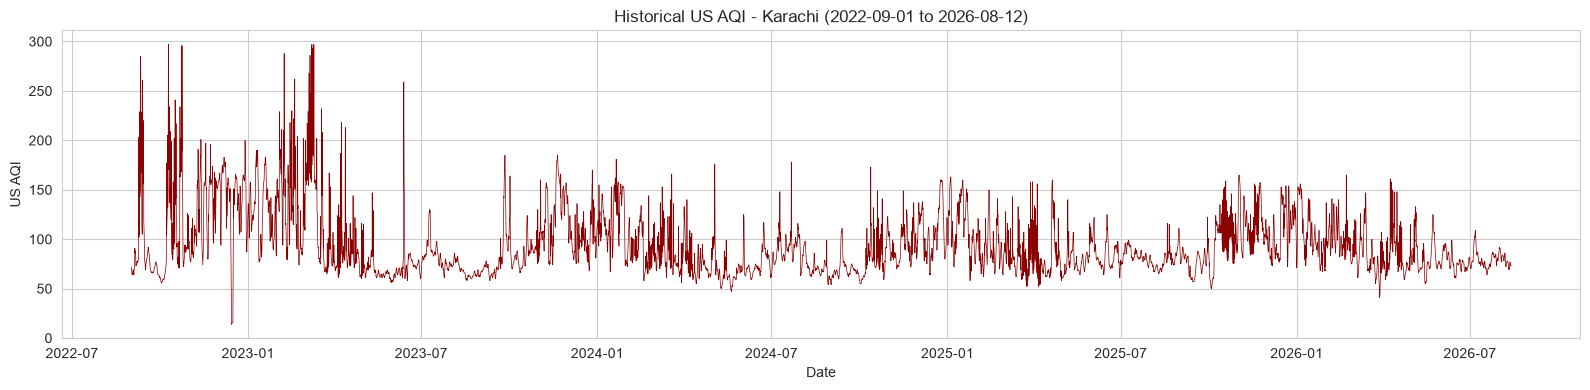

In [9]:
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(raw_df["timestamp"], raw_df["us_aqi"], linewidth=0.5, color="darkred")
ax.set_title(f"Historical US AQI - {CITY_NAME} ({raw_df['timestamp'].min().date()} to {raw_df['timestamp'].max().date()})")
ax.set_xlabel("Date"); ax.set_ylabel("US AQI")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "01_historical_aqi.png"), dpi=120)
plt.show()


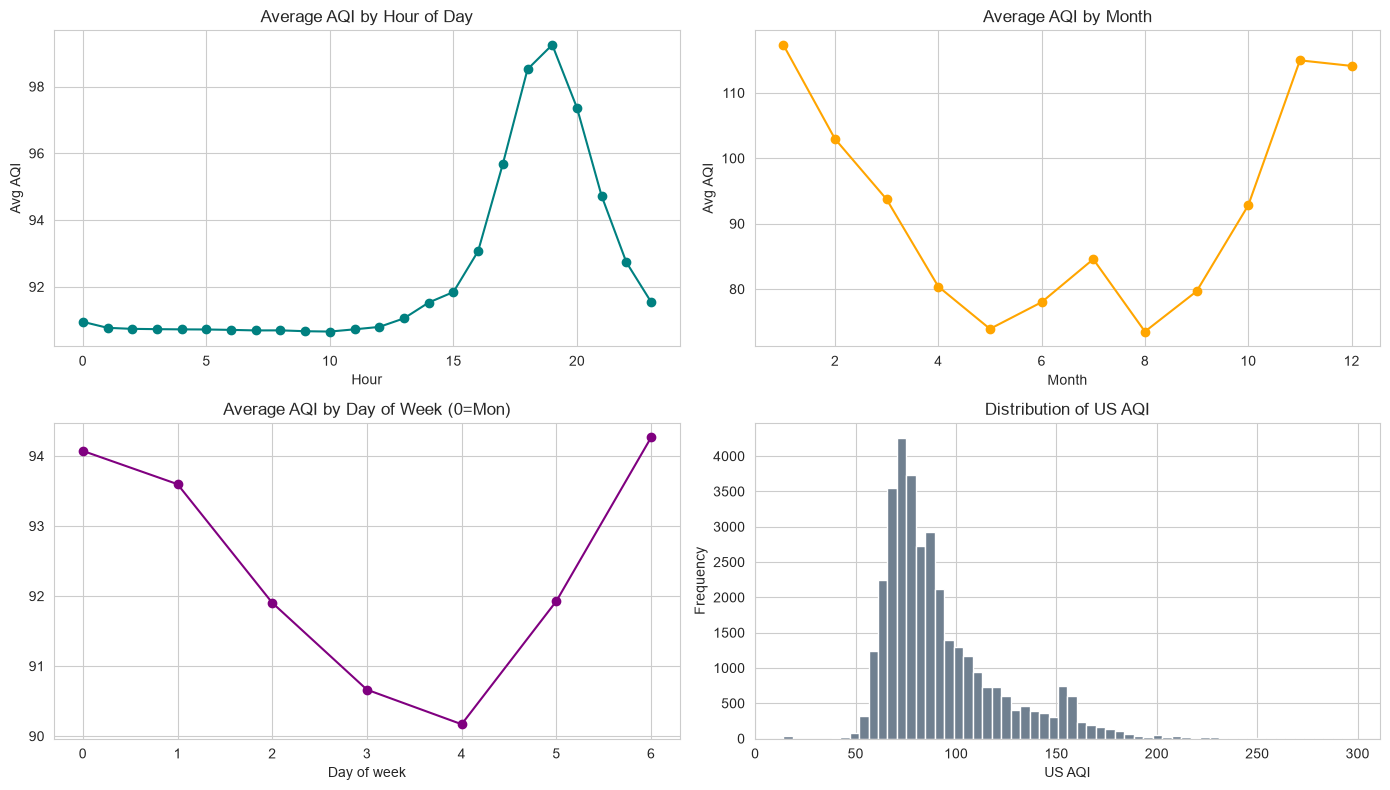

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
raw_df.groupby(raw_df["timestamp"].dt.hour)["us_aqi"].mean().plot(ax=axes[0,0], marker="o", color="teal")
axes[0,0].set_title("Average AQI by Hour of Day"); axes[0,0].set_xlabel("Hour"); axes[0,0].set_ylabel("Avg AQI")

raw_df.groupby(raw_df["timestamp"].dt.month)["us_aqi"].mean().plot(ax=axes[0,1], marker="o", color="orange")
axes[0,1].set_title("Average AQI by Month"); axes[0,1].set_xlabel("Month"); axes[0,1].set_ylabel("Avg AQI")

raw_df.groupby(raw_df["timestamp"].dt.dayofweek)["us_aqi"].mean().plot(ax=axes[1,0], marker="o", color="purple")
axes[1,0].set_title("Average AQI by Day of Week (0=Mon)"); axes[1,0].set_xlabel("Day of week")

raw_df["us_aqi"].plot(kind="hist", bins=60, ax=axes[1,1], color="slategray")
axes[1,1].set_title("Distribution of US AQI"); axes[1,1].set_xlabel("US AQI")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "02_aqi_by_hour_month_dow.png"), dpi=120)
plt.show()


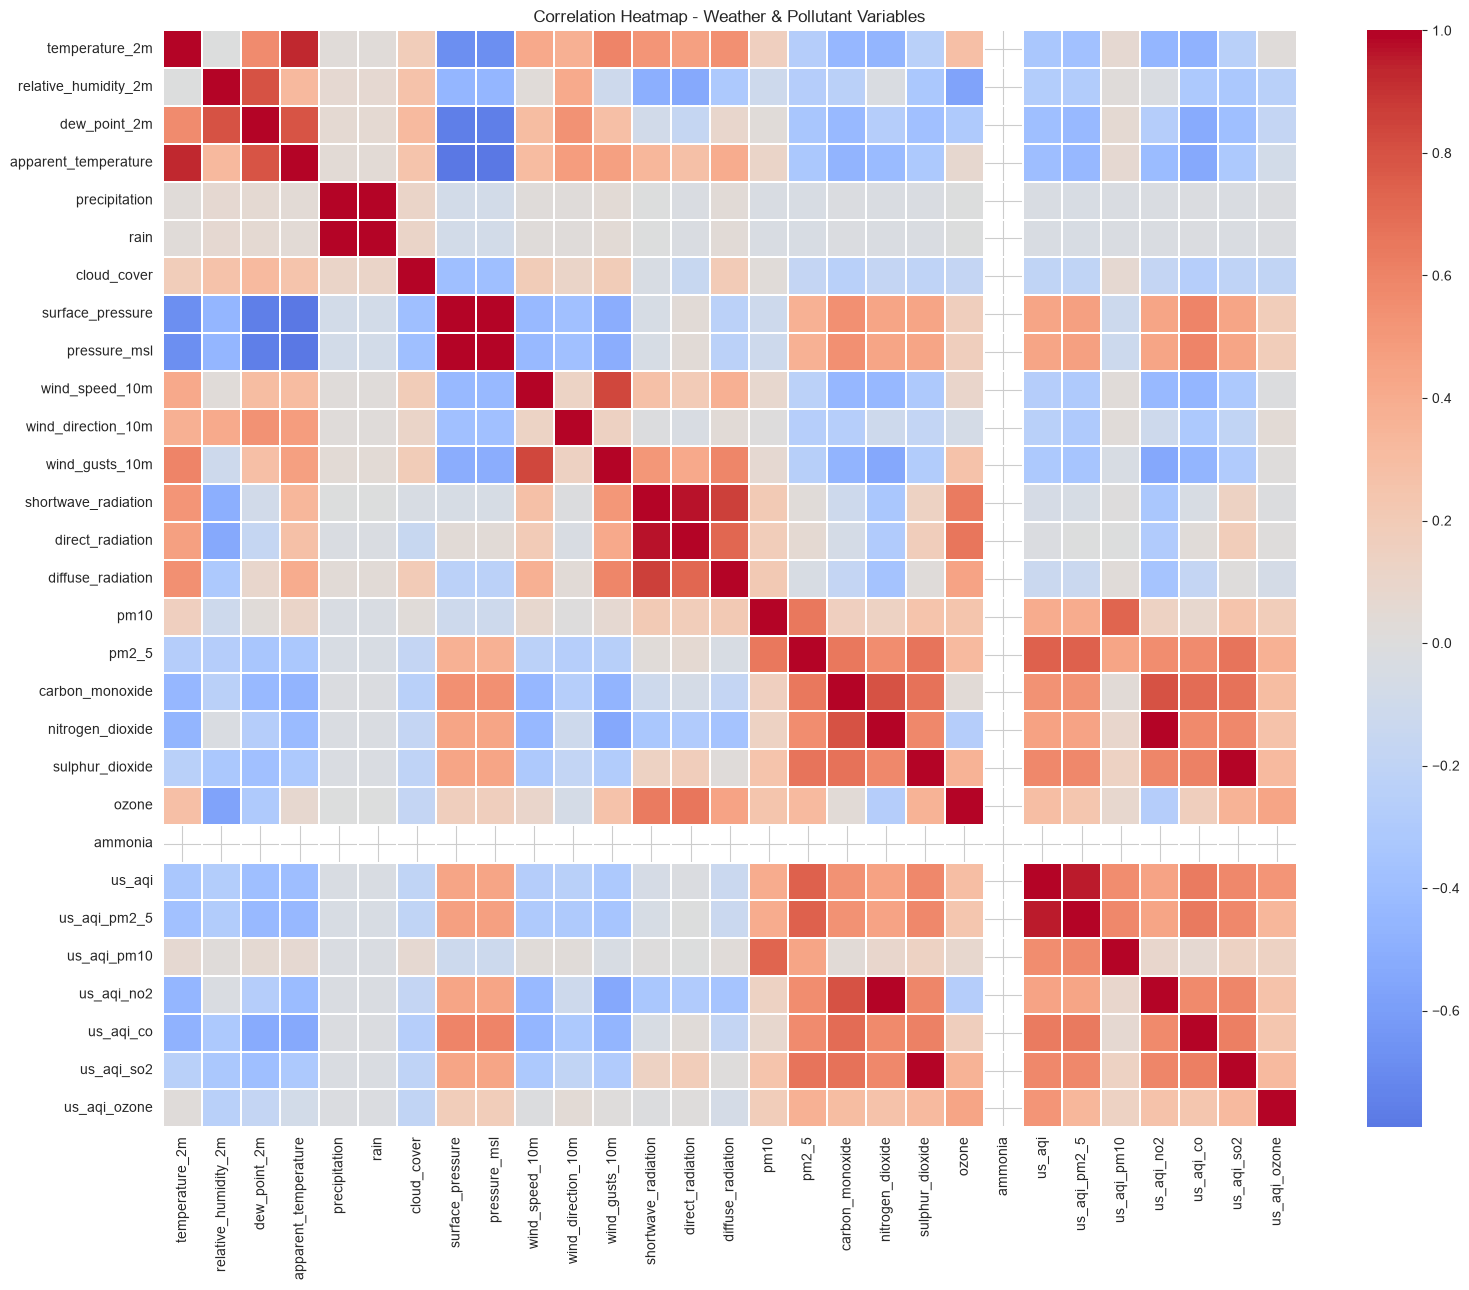

In [11]:
numeric_cols = raw_df.select_dtypes(include=[np.number]).columns.tolist()
corr = raw_df[numeric_cols].corr()
plt.figure(figsize=(16, 13))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, linewidths=0.2)
plt.title("Correlation Heatmap - Weather & Pollutant Variables")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "03_correlation_heatmap.png"), dpi=120)
plt.show()


## 6. Data Quality Analysis

We check for duplicate timestamps, missing values, timestamp gaps, and physically impossible values before doing anything else.

In [12]:
from data_pipeline import data_quality_report  

quality_report = data_quality_report(raw_df)
print(json.dumps(quality_report, indent=2, default=str))

with open(os.path.join(METRICS_DIR, "data_quality_report.json"), "w") as f:
    json.dump(quality_report, f, indent=2, default=str)


{
  "duplicate_timestamps": 0,
  "missing_by_column": {
    "ammonia": 100.0,
    "us_aqi_ozone": 0.02
  },
  "missing_hours_count": 0,
  "expected_hours": 34608,
  "actual_hours": 34608,
  "impossible_values": {
    "humidity_out_of_range": 0,
    "negative_pm25": 0,
    "negative_pm10": 0,
    "aqi_out_of_range": 0
  }
}


## 7. Data Preprocessing


In [13]:
from data_pipeline import clean_data  

clean_df = clean_data(raw_df)
print("Clean data shape:", clean_df.shape)
print("Remaining missing values:\\n", clean_df.isna().sum()[clean_df.isna().sum() > 0])

clean_df.to_csv(os.path.join(DATA_PROCESSED_DIR, "clean_hourly_data.csv"), index=False)


Dropped 0 rows with un-recoverable missing AQI (long gaps beyond 6h)
Clean data shape: (34608, 30)
Remaining missing values:\n ammonia    34608
dtype: int64


## 8. Feature Engineering



In [14]:

from feature_engineering import (
    LAG_TARGET_HOURS, LAG_POLLUTANT_HOURS, ROLLING_WINDOWS,
    POLLUTANT_COLS, WEATHER_COLS, EXTRA_WEATHER_PASSTHROUGH_COLS,
    add_lag_features, add_rolling_features, add_time_features,
    add_weather_engineered_features, create_features,
)

print("Imported shared feature-engineering functions from feature_engineering.py")
print(f"LAG_TARGET_HOURS={LAG_TARGET_HOURS}")
print(f"LAG_POLLUTANT_HOURS={LAG_POLLUTANT_HOURS}")
print(f"ROLLING_WINDOWS={ROLLING_WINDOWS}")

feature_df = create_features(clean_df)
print("\\nFeature-engineered shape:", feature_df.shape)
new_feature_cols = [c for c in feature_df.columns if c not in clean_df.columns]
print(f"\\nCreated {len(new_feature_cols)} new feature columns, e.g.:")
print(new_feature_cols[:25])


Imported shared feature-engineering functions from feature_engineering.py
LAG_TARGET_HOURS=[1, 2, 3, 6, 12, 24, 48, 72, 168]
LAG_POLLUTANT_HOURS=[1, 3, 6, 12, 24, 48, 72]
ROLLING_WINDOWS=[3, 6, 12, 24, 48]
\nFeature-engineered shape: (34608, 161)
\nCreated 131 new feature columns, e.g.:
['us_aqi_lag_1', 'us_aqi_lag_2', 'us_aqi_lag_3', 'us_aqi_lag_6', 'us_aqi_lag_12', 'us_aqi_lag_24', 'us_aqi_lag_48', 'us_aqi_lag_72', 'us_aqi_lag_168', 'us_aqi_rolling_mean_3', 'us_aqi_rolling_mean_6', 'us_aqi_rolling_mean_12', 'us_aqi_rolling_std_12', 'us_aqi_rolling_min_12', 'us_aqi_rolling_max_12', 'us_aqi_rolling_mean_24', 'us_aqi_rolling_std_24', 'us_aqi_rolling_min_24', 'us_aqi_rolling_max_24', 'us_aqi_rolling_mean_48', 'us_aqi_rolling_std_48', 'us_aqi_rolling_min_48', 'us_aqi_rolling_max_48', 'pm2_5_lag_1', 'pm2_5_lag_3']


## 9. Target Construction


In [15]:
def create_targets(df, horizons=(1, 24, 48, 72)):
    df = df.copy()
    for h in horizons:
        df[f"AQI_t+{h}"] = df["us_aqi"].shift(-h)
    return df

TARGET_HORIZONS = (1, 24, 48, 72)
target_df = create_targets(feature_df, horizons=TARGET_HORIZONS)


model_df = target_df.dropna(subset=[f"AQI_t+{h}" for h in TARGET_HORIZONS]).copy()
model_df = model_df.dropna(subset=[c for c in model_df.columns if "lag_168" in c])  

print("Modeling dataset shape (after dropping incomplete rows at both ends):", model_df.shape)
print("Date range:", model_df["timestamp"].min(), "->", model_df["timestamp"].max())


Modeling dataset shape (after dropping incomplete rows at both ends): (34368, 165)
Date range: 2022-09-08 00:00:00 -> 2026-08-09 23:00:00


## Feast Feature Store Setup



All Feast logic lives in `feast_utils.py` at the project root (imported here and again, unchanged, by `dashboard/app.py`) so training and serving use the exact same feature definitions and retrieval logic — Feast's "define once, reuse for training and serving" principle. The underlying feature-engineering functions (`create_features`, `add_lag_features`, ...) already live in `feature_engineering.py` for the same reason.

**Local setup, no cloud infrastructure:** offline store = **DuckDB** (reading a local Parquet file), online store = SQLite, provider = `local`. See `feature_store/feature_store.yaml`.

**Why DuckDB, not Feast's default "file" offline store:** the plain `file` store's point-in-time join does a pandas merge on the entity join key *before* filtering by timestamp. Since this project's entity is a single constant value (`location_id="karachi"`, one location), that merge matches every entity_df row against every offline-source row first - an O(n·m) cross product that reliably **runs out of memory** on the full multi-year hourly dataset (confirmed in practice: `MemoryError: Unable to allocate 8.80 GiB...` on the full run). DuckDB's offline store compiles the same point-in-time join into a single SQL query executed without materializing that cross product - same local/no-cloud setup, just a join engine that scales at this project's size. Requires `duckdb`, `ibis-framework[duckdb]`, `pyarrow_hotfix` (installed automatically by the cell above, also in `requirements.txt`).


**Leakage prevention, made structural rather than just a convention:** target columns (`AQI_t+1` ... `AQI_t+72`) are **never written into the Feast offline source** and **never appear in the FeatureView schema** — they physically cannot be requested as a Feast *feature*. They're instead carried on the `entity_df` passed into `get_historical_features()`, which is Feast's own recommended pattern for labels. Feast's point-in-time join then attaches only the feature values that were valid as of each row's `event_timestamp` — enforced by Feast itself, not by us remembering to `shift()` correctly a second time.

In [16]:
import feast_utils as fu
from feature_engineering import get_feature_columns

FEATURE_COLS = get_feature_columns(model_df, target_horizons=TARGET_HORIZONS)
print(f"Feature columns to be registered with Feast: {len(FEATURE_COLS)}")
print(FEATURE_COLS[:10], "...")

print(f"\\nFeast repo path : {fu.FEAST_REPO_PATH}")
print(f"Entity          : {fu.ENTITY_NAME} = '{fu.ENTITY_VALUE}'")
print(f"Feature view    : {fu.FEATURE_VIEW_NAME}")
print(f"Feature service : {fu.FEATURE_SERVICE_NAME}")


Feature columns to be registered with Feast: 159
['temperature_2m', 'relative_humidity_2m', 'dew_point_2m', 'apparent_temperature', 'precipitation', 'rain', 'cloud_cover', 'surface_pressure', 'pressure_msl', 'wind_speed_10m'] ...
\nFeast repo path : c:\Users\Asad\Desktop\Karachi AQI Project\karachi-aqi-forecasting\karachi-aqi-forecasting\feature_store
Entity          : location_id = 'karachi'
Feature view    : karachi_aqi_features
Feature service : karachi_aqi_service


## Register Feature Definitions

`feast apply` registers/updates the **Entity**, **FeatureView**, and **FeatureService** definitions into Feast's registry (`feature_store/data/registry.db`) and provisions the online store schema. We don't hand-write the FeatureView's column list — `generate_feature_views_file()` writes `feature_store/feature_views.py` directly from the real `FEATURE_COLS` list above, so the registered schema can never silently drift from what `create_features()` actually produces.

`feature_store/entities.py` (the `location_id` entity) is static and already exists in the repo; `feature_views.py` and `feature_service.py` are (re)generated by this cell every run.

**Implementation note:** `apply_feast_definitions()` calls Feast's Python SDK directly (`FeatureStore.apply([...])`) rather than shelling out to the `feast` CLI as a subprocess. On machines with multiple Python installations (common on Windows with conda), a subprocess call to `feast` can silently resolve to a *different* Python/Feast installation than the one running this notebook or the dashboard - producing exactly the kind of hard-to-diagnose bug where apply/materialize appear to succeed but the online store the dashboard reads from was never actually updated (symptoms: `no such table: ...` or a FeatureView stuck in state `MATERIALIZING`). Calling the SDK directly guarantees it always runs in the same interpreter as whatever imported `feast_utils`.

In [17]:
fu.write_offline_source(model_df, FEATURE_COLS)

fu.generate_feature_views_file(FEATURE_COLS)
fu.generate_feature_service_file()

try:
    fu.apply_feast_definitions()
except fu.FeastConfigError as e:
    print(f"FEAST CONFIGURATION ERROR: {e}")
    raise


Wrote 34,368 rows x 159 features to Feast offline source:
  c:\Users\Asad\Desktop\Karachi AQI Project\karachi-aqi-forecasting\karachi-aqi-forecasting\feature_store\data\karachi_features.parquet
Generated c:\Users\Asad\Desktop\Karachi AQI Project\karachi-aqi-forecasting\karachi-aqi-forecasting\feature_store\feature_views.py (159 feature fields)
Generated c:\Users\Asad\Desktop\Karachi AQI Project\karachi-aqi-forecasting\karachi-aqi-forecasting\feature_store\feature_service.py
Feast apply succeeded (via SDK, repo_path=c:\Users\Asad\Desktop\Karachi AQI Project\karachi-aqi-forecasting\karachi-aqi-forecasting\feature_store) - Entity, FeatureView 'karachi_aqi_features', and FeatureService 'karachi_aqi_service' are registered.


## Materialize Features


In [18]:
try:
    fu.materialize_feast_features(model_df["timestamp"].min(), model_df["timestamp"].max())
except fu.FeastConfigError as e:
    print(f"FEAST MATERIALIZATION ERROR: {e}")
    raise


Materializing 1 feature views from 2022-09-08 00:00:00+00:00 to 2026-08-09 23:00:00+00:00 into the sqlite online store.

karachi_aqi_features:
Materialized (via SDK) features from 2022-09-08 00:00:00+00:00 to 2026-08-09 23:00:00+00:00 into the online store.


## Retrieve Historical Features


In [19]:
training_df = fu.load_training_features_from_feast(model_df, target_horizons=TARGET_HORIZONS)

print("Training-ready DataFrame retrieved from Feast:")
print(training_df.shape)
display(training_df.head())

assert "AQI_t+1" in training_df.columns and "us_aqi" in training_df.columns
missing_features = [c for c in FEATURE_COLS if c not in training_df.columns]
assert not missing_features, f"Feast did not return expected features: {missing_features[:10]}"
print(f"\\nAll {len(FEATURE_COLS)} expected features + {len(TARGET_HORIZONS)} targets + 'us_aqi' present. OK.")


Requesting historical features from Feast for 34,368 entity rows via feature service 'karachi_aqi_service'...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Retrieved 34,368 rows x 166 columns from Feast (features + targets + entity/timestamp).
Training-ready DataFrame retrieved from Feast:
(34368, 166)


,us_aqi,AQI_t+1,AQI_t+24,AQI_t+48,AQI_t+72,location_id,timestamp,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,rain,cloud_cover,surface_pressure,pressure_msl,wind_speed_10m,wind_direction_10m,wind_gusts_10m,shortwave_radiation,direct_radiation,diffuse_radiation,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,ammonia,us_aqi_pm2_5,us_aqi_pm10,us_aqi_no2,us_aqi_co,us_aqi_so2,us_aqi_ozone,us_aqi_lag_1,us_aqi_lag_2,us_aqi_lag_3,us_aqi_lag_6,us_aqi_lag_12,us_aqi_lag_24,us_aqi_lag_48,us_aqi_lag_72,us_aqi_lag_168,us_aqi_rolling_mean_3,us_aqi_rolling_mean_6,us_aqi_rolling_mean_12,us_aqi_rolling_std_12,us_aqi_rolling_min_12,us_aqi_rolling_max_12,...,sulphur_dioxide_lag_72,sulphur_dioxide_rolling_mean_3,sulphur_dioxide_rolling_mean_6,sulphur_dioxide_rolling_mean_24,sulphur_dioxide_rolling_std_24,sulphur_dioxide_rolling_min_24,sulphur_dioxide_rolling_max_24,ozone_lag_1,ozone_lag_3,ozone_lag_6,ozone_lag_12,ozone_lag_24,ozone_lag_48,ozone_lag_72,ozone_rolling_mean_3,ozone_rolling_mean_6,ozone_rolling_mean_24,ozone_rolling_std_24,ozone_rolling_min_24,ozone_rolling_max_24,hour,day,day_of_week,day_of_month,month,quarter,week_of_year,day_of_year,is_weekend,sin_hour,cos_hour,sin_day_of_week,cos_day_of_week,sin_month,cos_month,temperature_2m_change_1h,temperature_2m_change_3h,relative_humidity_2m_change_1h,relative_humidity_2m_change_3h,surface_pressure_change_1h,surface_pressure_change_3h,wind_speed_10m_change_1h,wind_speed_10m_change_3h,temp_humidity_interaction,wind_dir_sin,wind_dir_cos,temperature_2m_rolling_mean_24,relative_humidity_2m_rolling_mean_24,wind_speed_10m_rolling_mean_24,low_dispersion_index
0,78,78.0,102.0,143.0,171.0,karachi,2022-09-08 00:00:00,25.900000,91.0,24.4,31.000000,0.0,0.0,0.0,1008.700012,1009.500000,8.8,289.0,11.500000,0.0,0.0,0.0,35.700001,20.400000,684.0,31.799999,29.600000,16.0,NaN,78.0,39.0,16.0,6.0,16.0,23.0,78.0,78.0,78.0,78.0,76.0,78.0,73.0,87.0,72.0,78.0,78.0,77.333336,0.887625,76.0,78.0,...,5.1,29.600000,26.233334,23.400000,16.280796,8.0,59.200001,13.0,5.0,78.0,102.0,34.0,39.0,44.0,8.333333,26.666666,61.208332,45.880733,5.0,153.0,0.0,8.0,3.0,8.0,9.0,3.0,36.0,251.0,0.0,0.000000,1.000000,0.433884,-0.900969,-1.0,-1.836970e-16,-0.3,-0.8,1.0,5.0,-0.2,0.7,0.8,-3.0,2356.899902,-0.945519,0.325568,27.016666,84.583336,12.741667,0.529929
1,78,78.0,103.0,144.0,171.0,karachi,2022-09-08 01:00:00,25.700001,93.0,24.5,30.500000,0.0,0.0,0.0,1008.099976,1008.900024,10.8,307.0,14.800000,0.0,0.0,0.0,34.299999,19.400000,573.0,26.900000,25.600000,21.0,NaN,78.0,39.0,13.0,6.0,14.0,16.0,78.0,78.0,78.0,78.0,76.0,78.0,74.0,87.0,71.0,78.0,78.0,77.500000,0.797724,76.0,78.0,...,4.8,30.433332,27.616667,24.158333,16.120630,8.0,59.200001,16.0,7.0,45.0,129.0,34.0,41.0,46.0,12.000000,16.333334,60.458332,46.487942,5.0,153.0,1.0,8.0,3.0,8.0,9.0,3.0,36.0,251.0,0.0,0.258819,0.965926,0.433884,-0.900969,-1.0,-1.836970e-16,-0.2,-0.8,2.0,5.0,-0.6,-0.6,2.0,0.8,2390.100098,-0.798635,0.601815,27.020834,84.541664,12.716666,0.525288
2,78,78.0,104.0,145.0,171.0,karachi,2022-09-08 02:00:00,25.500000,94.0,24.4,30.200001,0.0,0.0,1.0,1007.599976,1008.400024,11.5,314.0,15.800000,0.0,0.0,0.0,32.500000,18.200001,438.0,20.799999,20.799999,27.0,NaN,78.0,39.0,10.0,6.0,11.0,11.0,78.0,78.0,78.0,78.0,76.0,78.0,74.0,87.0,71.0,78.0,78.0,77.666664,0.651339,76.0,78.0,...,4.4,28.966667,28.116667,24.741667,15.898207,8.0,59.200001,21.0,13.0,12.0,152.0,34.0,44.0,49.0,16.666666,12.333333,59.916668,46.883682,5.0,153.0,2.0,8.0,3.0,8.0,9.0,3.0,36.0,251.0,0.0,0.500000,0.866025,0.433884,-0.900969,-1.0,-1.836970e-16,-0.2,-0.7,1.0,4.0,-0.5,-1.3,0.7,3.5,2397.000000,-0.719340,0.694658,27.025000,84.541664,12.820833,0.525371
3,78,78.0,104.0,146.0,171.0,karachi,2022-09-08 03:00:00,25.600000,92.0,24.1,29.900000,0.0,0.0,1.0,1007.400024,1008.200012,12.2,315.0,18.400000,0.0,0.0,0.0,30.900000,17.100000,357.0,16.200001,18.200001,31.0,NaN,78.0,39.0,8.0,6.0,10.0,8.0,78.0,78.0,78.0,78.0,77.0,78.0,74.0,87.0,70.0,78.0,78.0,77.833336,0.389249,77.0,7

\nAll 159 expected features + 4 targets + 'us_aqi' present. OK.


## Train Models Using Feast Features



## 10. Train / Validation / Test Split (Chronological)



In [20]:
def chronological_split(df, val_frac=0.10, test_frac=0.10):
    n = len(df)
    train_end = int(n * (1 - val_frac - test_frac))
    val_end = int(n * (1 - test_frac))

    train = df.iloc[:train_end].reset_index(drop=True)
    val = df.iloc[train_end:val_end].reset_index(drop=True)
    test = df.iloc[val_end:].reset_index(drop=True)
    return train, val, test


train_df, val_df, test_df = chronological_split(training_df, val_frac=0.10, test_frac=0.10)

print(f"Train : {len(train_df):6d} rows | {train_df['timestamp'].min()} -> {train_df['timestamp'].max()}")
print(f"Val   : {len(val_df):6d} rows | {val_df['timestamp'].min()} -> {val_df['timestamp'].max()}")
print(f"Test  : {len(test_df):6d} rows | {test_df['timestamp'].min()} -> {test_df['timestamp'].max()}")


print(f"\\nNumber of input features (from Feast): {len(FEATURE_COLS)}")

PRIMARY_TARGET = "AQI_t+1"

X_train, y_train = train_df[FEATURE_COLS], train_df[PRIMARY_TARGET]
X_val, y_val = val_df[FEATURE_COLS], val_df[PRIMARY_TARGET]
X_test, y_test = test_df[FEATURE_COLS], test_df[PRIMARY_TARGET]

print("X_train:", X_train.shape, "| X_val:", X_val.shape, "| X_test:", X_test.shape)


Train :  27494 rows | 2022-09-08 00:00:00 -> 2025-10-27 13:00:00
Val   :   3437 rows | 2025-10-27 14:00:00 -> 2026-03-19 18:00:00
Test  :   3437 rows | 2026-03-19 19:00:00 -> 2026-08-09 23:00:00
\nNumber of input features (from Feast): 159
X_train: (27494, 159) | X_val: (3437, 159) | X_test: (3437, 159)


## 17 (helper, used throughout). Evaluation Metrics Function

Defined early so every model section below can call it consistently.

In [21]:
def evaluate_predictions(y_true, y_pred, model_name="model"):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    medae = median_absolute_error(y_true, y_pred)
    evs = explained_variance_score(y_true, y_pred)

  
    mask = y_true > 10
    mape = float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100) if mask.sum() > 0 else np.nan

    return {
        "model": model_name, "MAE": round(mae, 3), "RMSE": round(rmse, 3),
        "R2": round(r2, 4), "MedAE": round(medae, 3), "MAPE_%": round(mape, 2) if not np.isnan(mape) else None,
        "Explained_Variance": round(evs, 4),
    }

model_results = []        
trained_models = {}        
model_train_times = {}     


## 11. Baseline Models

Before any ML, we establish naive baselines. **Any ML model that can't beat these isn't earning its complexity.**

- **Naive persistence:** `AQI(t+1) ≈ AQI(t)`
- **Seasonal persistence:** `AQI(t+1) ≈ AQI(t-23)` (same hour, previous day)

In [22]:

pred_naive = X_test["us_aqi_lag_1"]
res = evaluate_predictions(y_test, pred_naive, "Baseline: Naive Persistence")
model_results.append(res); print(res)


pred_seasonal = X_test["us_aqi_lag_24"]
res = evaluate_predictions(y_test, pred_seasonal, "Baseline: Seasonal Persistence (t-24h)")
model_results.append(res); print(res)


{'model': 'Baseline: Naive Persistence', 'MAE': 1.679, 'RMSE': 4.583, 'R2': 0.8888, 'MedAE': 1.0, 'MAPE_%': 1.92, 'Explained_Variance': 0.8888}
{'model': 'Baseline: Seasonal Persistence (t-24h)', 'MAE': 8.417, 'RMSE': 12.154, 'R2': 0.2177, 'MedAE': 6.0, 'MAPE_%': 10.38, 'Explained_Variance': 0.2177}


## 12. Machine Learning Models



In [23]:
def train_and_evaluate(model, name, X_tr, y_tr, X_ev, y_ev):
    t0 = time.time()
    model.fit(X_tr, y_tr)
    elapsed = time.time() - t0
    preds = model.predict(X_ev)
    res = evaluate_predictions(y_ev, preds, name)
    res["Training_Time_s"] = round(elapsed, 2)
    trained_models[name] = model
    model_train_times[name] = elapsed
    model_results.append(res)
    print(res)
    return model, preds


In [24]:
rf = RandomForestRegressor(n_estimators=300, max_depth=16, min_samples_leaf=3, n_jobs=-1, random_state=42)
rf_model, rf_val_preds = train_and_evaluate(rf, "Random Forest", X_train, y_train, X_val, y_val)


{'model': 'Random Forest', 'MAE': 0.598, 'RMSE': 1.048, 'R2': 0.9979, 'MedAE': 0.372, 'MAPE_%': 0.57, 'Explained_Variance': 0.9979, 'Training_Time_s': 183.74}


In [25]:
et = ExtraTreesRegressor(n_estimators=300, max_depth=18, min_samples_leaf=3, n_jobs=-1, random_state=42)
et_model, et_val_preds = train_and_evaluate(et, "Extra Trees", X_train, y_train, X_val, y_val)


{'model': 'Extra Trees', 'MAE': 0.624, 'RMSE': 1.042, 'R2': 0.998, 'MedAE': 0.399, 'MAPE_%': 0.6, 'Explained_Variance': 0.998, 'Training_Time_s': 54.22}


In [26]:
hgb = HistGradientBoostingRegressor(max_iter=400, max_depth=8, learning_rate=0.05,
                                     early_stopping=True, random_state=42)
hgb_model, hgb_val_preds = train_and_evaluate(hgb, "HistGradientBoosting", X_train, y_train, X_val, y_val)


ValueError: window shape cannot be larger than input array shape

In [27]:
gb = GradientBoostingRegressor(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42)
gb_model, gb_val_preds = train_and_evaluate(gb, "Gradient Boosting (sklearn)", X_train, y_train, X_val, y_val)


ValueError: Input X contains NaN.
GradientBoostingRegressor does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [28]:
if HAS_LIGHTGBM:
    lgbm = lgb.LGBMRegressor(n_estimators=600, max_depth=8, learning_rate=0.03, num_leaves=64,
                              subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, verbose=-1)
    lgbm_model, lgbm_val_preds = train_and_evaluate(lgbm, "LightGBM", X_train, y_train, X_val, y_val)
else:
    print("LightGBM not available - skipping (HistGradientBoosting above serves as the closest fallback).")
    lgbm_model = None


{'model': 'LightGBM', 'MAE': 0.541, 'RMSE': 0.935, 'R2': 0.9984, 'MedAE': 0.359, 'MAPE_%': 0.52, 'Explained_Variance': 0.9984, 'Training_Time_s': 4.14}


In [29]:
if HAS_XGBOOST:
    xgb_model_obj = xgb.XGBRegressor(n_estimators=600, max_depth=7, learning_rate=0.03,
                                      subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1,
                                      tree_method="hist")
    xgb_model, xgb_val_preds = train_and_evaluate(xgb_model_obj, "XGBoost", X_train, y_train, X_val, y_val)
else:
    print("XGBoost not available - skipping.")
    xgb_model = None


{'model': 'XGBoost', 'MAE': 0.506, 'RMSE': 0.867, 'R2': 0.9986, 'MedAE': 0.332, 'MAPE_%': 0.49, 'Explained_Variance': 0.9986, 'Training_Time_s': 20.11}


In [30]:
if HAS_CATBOOST:
    cat_model_obj = cb.CatBoostRegressor(iterations=600, depth=8, learning_rate=0.03,
                                          loss_function="RMSE", random_seed=42, verbose=False)
    cat_model, cat_val_preds = train_and_evaluate(cat_model_obj, "CatBoost", X_train, y_train, X_val, y_val)
else:
    print("CatBoost not available - skipping.")
    cat_model = None


{'model': 'CatBoost', 'MAE': 1.04, 'RMSE': 1.553, 'R2': 0.9955, 'MedAE': 0.709, 'MAPE_%': 0.99, 'Explained_Variance': 0.9955, 'Training_Time_s': 44.42}


## 13. Ridge Regression



In [31]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns, index=X_val.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

ridge = Ridge(alpha=10.0, random_state=42)
ridge_model, ridge_val_preds = train_and_evaluate(ridge, "Ridge Regression", X_train_scaled, y_train, X_val_scaled, y_val)


alpha_results = []
for alpha in [0.1, 1.0, 10.0, 50.0, 100.0]:
    r = Ridge(alpha=alpha, random_state=42).fit(X_train_scaled, y_train)
    val_mae = mean_absolute_error(y_val, r.predict(X_val_scaled))
    alpha_results.append((alpha, val_mae))
print("\\nAlpha sweep (validation MAE):")
for a, m in alpha_results:
    print(f"  alpha={a:<7} MAE={m:.3f}")


ValueError: Input X contains NaN.
Ridge does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

## 14. Deep Learning Model (LSTM)


In [32]:
SEQ_LEN = 24 if FAST_MODE else 48   

def build_sequences(X_scaled_df, y_series, seq_len):
    X_arr = X_scaled_df.values.astype("float32")
    y_arr = y_series.values.astype("float32")
    n = len(X_arr) - seq_len
    if n <= 0:
        raise ValueError("Not enough rows to build sequences of this length.")
    X_seq = np.zeros((n, seq_len, X_arr.shape[1]), dtype="float32")
    y_seq = np.zeros((n,), dtype="float32")
    for i in range(n):
        X_seq[i] = X_arr[i:i + seq_len]
        y_seq[i] = y_arr[i + seq_len]
    return X_seq, y_seq

if HAS_TENSORFLOW:
    X_train_seq, y_train_seq = build_sequences(X_train_scaled, y_train, SEQ_LEN)
    X_val_seq, y_val_seq = build_sequences(X_val_scaled, y_val, SEQ_LEN)
    X_test_seq, y_test_seq = build_sequences(X_test_scaled, y_test, SEQ_LEN)
    print("LSTM sequence shapes:", X_train_seq.shape, X_val_seq.shape, X_test_seq.shape)
else:
    print("TensorFlow not available - deep learning section will be skipped.")


LSTM sequence shapes: (27470, 24, 159) (3413, 24, 159) (3413, 24, 159)


Epoch 1/15
215/215 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - loss: 92.5424 - mae: 92.5424 - val_loss: 103.8993 - val_mae: 103.8993
Epoch 2/15
215/215 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 92.3274 - mae: 92.3274 - val_loss: 103.6843 - val_mae: 103.6843
Epoch 3/15
215/215 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 92.1124 - mae: 92.1124 - val_loss: 103.4693 - val_mae: 103.4693
Epoch 4/15
215/215 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 91.8973 - mae: 91.8973 - val_loss: 103.2543 - val_mae: 103.2543
Epoch 5/15
215/215 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 91.6823 - mae: 91.6823 - val_loss: 103.0393 - val_mae: 103.0393
Epoch 6/15
215/215 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 91.4673 - mae: 91.4673 - val_loss: 102.8242 - val_mae: 102.8242
Epoch 7/15
215/215 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 91.2523 - mae: 91.2523 - val_loss: 102.6093 - val_mae: 102.6093
Epoch 8/15
215/215 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 91.0374 - mae: 91.0374 - val_loss: 102.3943 - val_mae: 102.3943


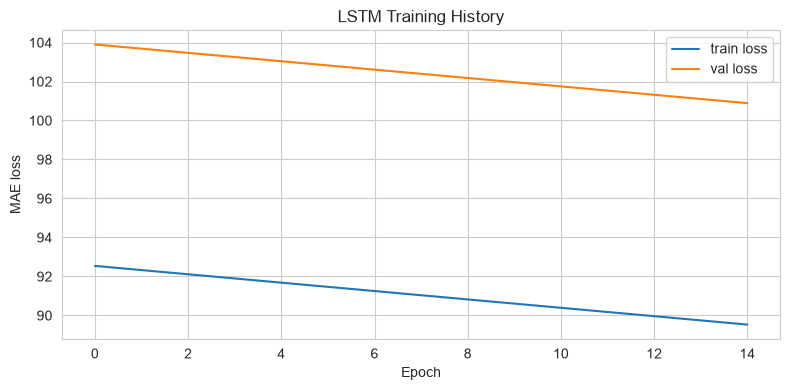

In [33]:
if HAS_TENSORFLOW:
    n_features = X_train_seq.shape[2]
    hidden_units = 32 if FAST_MODE else 64
    dropout_rate = 0.2
    epochs = 15 if FAST_MODE else 40
    batch_size = 128

    lstm_model = keras.Sequential([
        layers.Input(shape=(SEQ_LEN, n_features)),
        layers.LSTM(hidden_units, return_sequences=True),
        layers.Dropout(dropout_rate),
        layers.LSTM(hidden_units // 2),
        layers.Dropout(dropout_rate),
        layers.Dense(32, activation="relu"),
        layers.Dense(1),
    ])
    lstm_model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss="mae", metrics=["mae"])

    early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

    t0 = time.time()
    history = lstm_model.fit(
        X_train_seq, y_train_seq,
        validation_data=(X_val_seq, y_val_seq),
        epochs=epochs, batch_size=batch_size,
        callbacks=[early_stop], verbose=1,
    )
    lstm_train_time = time.time() - t0

    lstm_val_preds = lstm_model.predict(X_val_seq, verbose=0).flatten()
    res = evaluate_predictions(y_val_seq, lstm_val_preds, "LSTM")
    res["Training_Time_s"] = round(lstm_train_time, 2)
    model_results.append(res)
    trained_models["LSTM"] = lstm_model
    print(res)

    plt.figure(figsize=(8, 4))
    plt.plot(history.history["loss"], label="train loss")
    plt.plot(history.history["val_loss"], label="val loss")
    plt.title("LSTM Training History"); plt.xlabel("Epoch"); plt.ylabel("MAE loss"); plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, "04_lstm_training_history.png"), dpi=120)
    plt.show()
else:
    print("Skipped: TensorFlow unavailable.")


In [34]:
if HAS_TENSORFLOW:
    tree_results_so_far = [r for r in model_results if r["model"] not in ("LSTM",) and "Baseline" not in r["model"]]
    if tree_results_so_far:
        best_tree_mae = min(r["MAE"] for r in tree_results_so_far)
        lstm_mae = [r for r in model_results if r["model"] == "LSTM"][0]["MAE"]
        if lstm_mae > best_tree_mae:
            print(f"NOTE: LSTM validation MAE ({lstm_mae}) is WORSE than the best tree model ({best_tree_mae}).")
            print("This is common for tabular, feature-engineered time series (tree models tend to dominate here).")
            print("The LSTM will still be considered as a candidate ensemble member in Section 16, but only kept")
            print("if it actually improves the blended validation score - never included 'for appearance'.")
        else:
            print(f"LSTM validation MAE ({lstm_mae}) BEATS the best tree model ({best_tree_mae}).")


NOTE: LSTM validation MAE (100.889) is WORSE than the best tree model (0.506).
This is common for tabular, feature-engineered time series (tree models tend to dominate here).
The LSTM will still be considered as a candidate ensemble member in Section 16, but only kept
if it actually improves the blended validation score - never included 'for appearance'.


## 15. Hyperparameter Optimization



In [35]:
N_TRIALS = 15 if FAST_MODE else 60
best_params = {}

def run_optuna(objective_fn, name, n_trials=N_TRIALS):
    study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective_fn, n_trials=n_trials, show_progress_bar=False)
    print(f"[{name}] Best val MAE: {study.best_value:.3f}")
    print(f"[{name}] Best params: {study.best_params}")
    best_params[name] = study.best_params
    return study


In [36]:
if HAS_OPTUNA:
    def rf_objective(trial):
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 150, 500),
            "max_depth": trial.suggest_int("max_depth", 6, 24),
            "min_samples_split": trial.suggest_int("min_samples_split", 2, 12),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 8),
            "max_features": trial.suggest_float("max_features", 0.4, 1.0),
        }
        m = RandomForestRegressor(**params, n_jobs=-1, random_state=42)
        m.fit(X_train, y_train)
        return mean_absolute_error(y_val, m.predict(X_val))

    study_rf = run_optuna(rf_objective, "Random Forest")
else:
    from sklearn.model_selection import RandomizedSearchCV
    tscv = TimeSeriesSplit(n_splits=3)
    param_dist = {"n_estimators": [150, 300, 500], "max_depth": [8, 12, 16, 20],
                  "min_samples_leaf": [1, 3, 5]}
    rs = RandomizedSearchCV(RandomForestRegressor(random_state=42, n_jobs=-1), param_dist,
                             n_iter=8, cv=tscv, scoring="neg_mean_absolute_error", random_state=42)
    rs.fit(pd.concat([X_train, X_val]), pd.concat([y_train, y_val]))
    best_params["Random Forest"] = rs.best_params_
    print("Best params (RandomizedSearchCV fallback):", rs.best_params_)


[Random Forest] Best val MAE: 0.593
[Random Forest] Best params: {'n_estimators': 494, 'max_depth': 19, 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 0.8631544074280426}


In [37]:
if HAS_OPTUNA and HAS_LIGHTGBM:
    def lgbm_objective(trial):
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 200, 900),
            "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
            "num_leaves": trial.suggest_int("num_leaves", 16, 128),
            "max_depth": trial.suggest_int("max_depth", 4, 12),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "min_child_samples": trial.suggest_int("min_child_samples", 5, 60),
        }
        m = lgb.LGBMRegressor(**params, random_state=42, n_jobs=-1, verbose=-1)
        m.fit(X_train, y_train)
        return mean_absolute_error(y_val, m.predict(X_val))

    study_lgbm = run_optuna(lgbm_objective, "LightGBM")
else:
    print("Skipping LightGBM tuning (Optuna and/or LightGBM unavailable).")


[LightGBM] Best val MAE: 0.485
[LightGBM] Best params: {'n_estimators': 560, 'learning_rate': 0.03732247640211544, 'num_leaves': 125, 'max_depth': 12, 'subsample': 0.6086600582523732, 'colsample_bytree': 0.8163775632702192, 'min_child_samples': 5}


In [ ]:
if HAS_OPTUNA and HAS_XGBOOST:
    def xgb_objective(trial):
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 200, 900),
            "max_depth": trial.suggest_int("max_depth", 3, 10),
            "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        }
        m = xgb.XGBRegressor(**params, random_state=42, n_jobs=-1, tree_method="hist")
        m.fit(X_train, y_train)
        return mean_absolute_error(y_val, m.predict(X_val))

    study_xgb = run_optuna(xgb_objective, "XGBoost")
else:
    print("Skipping XGBoost tuning (Optuna and/or XGBoost unavailable).")


In [ ]:
if HAS_OPTUNA:
    def ridge_objective(trial):
        alpha = trial.suggest_float("alpha", 0.01, 200.0, log=True)
        m = Ridge(alpha=alpha, random_state=42)
        m.fit(X_train_scaled, y_train)
        return mean_absolute_error(y_val, m.predict(X_val_scaled))

    study_ridge = run_optuna(ridge_objective, "Ridge Regression", n_trials=min(N_TRIALS, 25))


In [ ]:
tuned_model_results = []

if "Random Forest" in best_params:
    m = RandomForestRegressor(**best_params["Random Forest"], n_jobs=-1, random_state=42)
    _, _ = train_and_evaluate(m, "Random Forest (Tuned)", X_train, y_train, X_val, y_val)

if HAS_LIGHTGBM and "LightGBM" in best_params:
    m = lgb.LGBMRegressor(**best_params["LightGBM"], random_state=42, n_jobs=-1, verbose=-1)
    _, _ = train_and_evaluate(m, "LightGBM (Tuned)", X_train, y_train, X_val, y_val)

if HAS_XGBOOST and "XGBoost" in best_params:
    m = xgb.XGBRegressor(**best_params["XGBoost"], random_state=42, n_jobs=-1, tree_method="hist")
    _, _ = train_and_evaluate(m, "XGBoost (Tuned)", X_train, y_train, X_val, y_val)

if "Ridge Regression" in best_params:
    m = Ridge(alpha=best_params["Ridge Regression"]["alpha"], random_state=42)
    _, _ = train_and_evaluate(m, "Ridge Regression (Tuned)", X_train_scaled, y_train, X_val_scaled, y_val)

print("\\nTuning complete. Tuned models are now in `trained_models` and `model_results` alongside the originals.")


## 16. Ensemble Modeling


In [ ]:
from scipy.optimize import minimize
candidate_preds_val = {}
candidate_preds_test = {}

def get_val_test_preds(model_name, model_obj, use_scaled=False):
    Xv = X_val_scaled if use_scaled else X_val
    Xt = X_test_scaled if use_scaled else X_test
    return model_obj.predict(Xv), model_obj.predict(Xt)

_candidates = [
    ("Random Forest (Tuned)" if "Random Forest (Tuned)" in trained_models else "Random Forest", False),
    ("Extra Trees", False),
    ("HistGradientBoosting", False),
]
if HAS_LIGHTGBM:
    _candidates.append(("LightGBM (Tuned)" if "LightGBM (Tuned)" in trained_models else "LightGBM", False))
if HAS_XGBOOST:
    _candidates.append(("XGBoost (Tuned)" if "XGBoost (Tuned)" in trained_models else "XGBoost", False))
if HAS_CATBOOST and "CatBoost" in trained_models:
    _candidates.append(("CatBoost", False))
_candidates.append(("Ridge Regression (Tuned)" if "Ridge Regression (Tuned)" in trained_models else "Ridge Regression", True))

for name, use_scaled in _candidates:
    if name in trained_models:
        vp, tp = get_val_test_preds(name, trained_models[name], use_scaled)
        candidate_preds_val[name] = vp
        candidate_preds_test[name] = tp

lstm_included = False
if HAS_TENSORFLOW and "LSTM" in trained_models:
    lstm_val_full = trained_models["LSTM"].predict(X_val_seq, verbose=0).flatten()
    lstm_test_full = trained_models["LSTM"].predict(X_test_seq, verbose=0).flatten()
    lstm_included = True

print("Ensemble candidates (validation MAE):")
for name, preds in candidate_preds_val.items():
    print(f"  {name:30s} MAE={mean_absolute_error(y_val, preds):.3f}")


In [ ]:
candidate_names = list(candidate_preds_val.keys())
val_pred_matrix = np.column_stack([candidate_preds_val[n] for n in candidate_names])
y_val_arr = y_val.values

def neg_weighted_mae(weights, preds_matrix, y_true):
    weights = np.clip(weights, 0, None)
    weights = weights / weights.sum()
    blended = preds_matrix @ weights
    return mean_absolute_error(y_true, blended)

n_models = len(candidate_names)
init_weights = np.ones(n_models) / n_models
constraints = ({"type": "eq", "fun": lambda w: np.sum(w) - 1},)
bounds = [(0, 1)] * n_models

opt_result = minimize(neg_weighted_mae, init_weights, args=(val_pred_matrix, y_val_arr),
                       method="SLSQP", bounds=bounds, constraints=constraints)
optimal_weights = np.clip(opt_result.x, 0, None)
optimal_weights = optimal_weights / optimal_weights.sum()

print("Optimal ensemble weights (validation-based):")
for name, w in sorted(zip(candidate_names, optimal_weights), key=lambda x: -x[1]):
    print(f"  {name:30s} weight={w:.3f}")

ensemble_val_preds = val_pred_matrix @ optimal_weights
ensemble_val_mae = mean_absolute_error(y_val, ensemble_val_preds)

best_single_mae = min(mean_absolute_error(y_val, candidate_preds_val[n]) for n in candidate_names)
print(f"\\nBest single model val MAE : {best_single_mae:.3f}")
print(f"Weighted ensemble val MAE : {ensemble_val_mae:.3f}")

ENSEMBLE_HELPS = ensemble_val_mae < best_single_mae
print(f"\\nEnsemble improves on best single model: {ENSEMBLE_HELPS}")


In [ ]:
WEIGHT_THRESHOLD = 0.03
kept_names = [n for n, w in zip(candidate_names, optimal_weights) if w >= WEIGHT_THRESHOLD]
print("Models kept in final ensemble (weight >= %.2f):" % WEIGHT_THRESHOLD, kept_names)

if len(kept_names) >= 2:
    kept_idx = [candidate_names.index(n) for n in kept_names]
    trimmed_matrix = val_pred_matrix[:, kept_idx]
    trimmed_init = np.ones(len(kept_names)) / len(kept_names)
    trimmed_bounds = [(0, 1)] * len(kept_names)
    trimmed_result = minimize(neg_weighted_mae, trimmed_init, args=(trimmed_matrix, y_val_arr),
                               method="SLSQP", bounds=trimmed_bounds, constraints=constraints)
    final_weights = np.clip(trimmed_result.x, 0, None)
    final_weights = final_weights / final_weights.sum()
else:
    kept_names = candidate_names
    final_weights = optimal_weights

ENSEMBLE_WEIGHTS = dict(zip(kept_names, final_weights))
print("\\nFinal ensemble composition:")
for name, w in ENSEMBLE_WEIGHTS.items():
    print(f"  {name:30s} weight={w:.3f}")

test_pred_matrix = np.column_stack([candidate_preds_test[n] for n in kept_names])
ensemble_test_preds = test_pred_matrix @ final_weights
ensemble_val_matrix2 = np.column_stack([candidate_preds_val[n] for n in kept_names])
ensemble_val_preds_final = ensemble_val_matrix2 @ final_weights

res_val = evaluate_predictions(y_val, ensemble_val_preds_final, "Weighted Ensemble")
model_results.append(res_val)
print("\\nFinal ensemble (validation):", res_val)


## 17. Model Evaluation — Comparison Table



In [ ]:
results_df = pd.DataFrame(model_results).drop_duplicates(subset="model", keep="last")
results_df = results_df.sort_values("MAE").reset_index(drop=True)
results_df.to_csv(os.path.join(METRICS_DIR, "model_comparison.csv"), index=False)
results_df


In [ ]:
plt.figure(figsize=(10, max(4, 0.4 * len(results_df))))
plot_df = results_df[~results_df["model"].str.contains("Baseline")].sort_values("MAE")
sns.barplot(data=plot_df, y="model", x="MAE", palette="viridis")
plt.title("Model Comparison - Validation MAE (lower is better)")
plt.xlabel("MAE (AQI points)"); plt.ylabel("")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "05_model_comparison.png"), dpi=120)
plt.show()


## 20. Final Model Selection


In [ ]:
best_by_mae = results_df.loc[results_df["MAE"].idxmin()]
best_by_rmse = results_df.loc[results_df["RMSE"].idxmin()]
best_by_r2 = results_df.loc[results_df["R2"].idxmax()]

print("BEST MODEL BY MAE :", best_by_mae["model"], f"(MAE={best_by_mae['MAE']})")
print("BEST MODEL BY RMSE:", best_by_rmse["model"], f"(RMSE={best_by_rmse['RMSE']})")
print("BEST MODEL BY R2  :", best_by_r2["model"], f"(R2={best_by_r2['R2']})")

FINAL_MODEL_NAME = best_by_mae["model"]
print(f"\\nSelected production model (lowest validation MAE): {FINAL_MODEL_NAME}")


In [ ]:
if FINAL_MODEL_NAME == "Weighted Ensemble":
    final_test_preds = ensemble_test_preds
elif FINAL_MODEL_NAME in trained_models:
    is_ridge_like = "Ridge" in FINAL_MODEL_NAME
    final_test_preds = trained_models[FINAL_MODEL_NAME].predict(X_test_scaled if is_ridge_like else X_test)
else:
    raise RuntimeError(f"Could not locate a predictor for '{FINAL_MODEL_NAME}'")

final_test_metrics = evaluate_predictions(y_test, final_test_preds, f"{FINAL_MODEL_NAME} (TEST)")
print("Final model performance on held-out TEST set:")
print(json.dumps(final_test_metrics, indent=2))

with open(os.path.join(METRICS_DIR, "final_model_test_metrics.json"), "w") as f:
    json.dump(final_test_metrics, f, indent=2)


## 18. Error Analysis


In [ ]:
direct_horizon_results = []
DirectModelClass = (lambda: lgb.LGBMRegressor(n_estimators=400, max_depth=8, learning_rate=0.05, random_state=42, n_jobs=-1, verbose=-1)) if HAS_LIGHTGBM \
    else (lambda: HistGradientBoostingRegressor(max_iter=300, max_depth=8, random_state=42))

for h in TARGET_HORIZONS:
    target_col = f"AQI_t+{h}"
    y_tr_h = train_df[target_col]
    y_val_h = val_df[target_col]
    m = DirectModelClass()
    m.fit(X_train, y_tr_h)
    preds_h = m.predict(X_val)
    res = evaluate_predictions(y_val_h, preds_h, f"Direct model @ t+{h}h")
    direct_horizon_results.append(res)

direct_horizon_df = pd.DataFrame(direct_horizon_results)
direct_horizon_df


In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(TARGET_HORIZONS, direct_horizon_df["MAE"], marker="o", label="MAE")
plt.xlabel("Forecast horizon (hours ahead)"); plt.ylabel("MAE (AQI points)")
plt.title("Direct-Forecasting Error Growth by Horizon\n(illustrates why recursive forecasting needs its own backtest)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "06_direct_horizon_degradation.png"), dpi=120)
plt.show()
print("As expected, direct-model error grows with horizon - forecasting further ahead is fundamentally harder.")
print("This is why Section 21/32 evaluate the RECURSIVE strategy specifically for the 72-hour deliverable.")


In [ ]:
error_df = test_df[["timestamp", "hour", "us_aqi"]].copy()
error_df["y_true"] = y_test.values
error_df["y_pred"] = final_test_preds
error_df["abs_error"] = np.abs(error_df["y_true"] - error_df["y_pred"])
error_df["is_night"] = ((error_df["hour"] >= 20) | (error_df["hour"] <= 5)).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

error_df.groupby("hour")["abs_error"].mean().plot(ax=axes[0], marker="o", color="crimson")
axes[0].set_title("Mean Absolute Error by Hour of Day"); axes[0].set_xlabel("Hour"); axes[0].set_ylabel("MAE")

error_df["aqi_bin"] = pd.cut(error_df["y_true"], bins=[0, 50, 100, 150, 200, 300, 500],
                              labels=["Good\n(0-50)", "Moderate\n(51-100)", "USG\n(101-150)",
                                      "Unhealthy\n(151-200)", "V.Unhealthy\n(201-300)", "Hazardous\n(301+)"])
error_df.groupby("aqi_bin", observed=True)["abs_error"].mean().plot(kind="bar", ax=axes[1], color="darkorange")
axes[1].set_title("MAE by True AQI Category"); axes[1].set_xlabel(""); axes[1].tick_params(axis="x", rotation=30)

error_df.groupby("is_night")["abs_error"].mean().rename({0: "Day", 1: "Night"}).plot(kind="bar", ax=axes[2], color=["gold", "navy"])
axes[2].set_title("MAE: Day vs Night"); axes[2].set_xlabel("")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "07_error_analysis.png"), dpi=120)
plt.show()

print("Does the model perform worse during pollution spikes?")
print(error_df.groupby("aqi_bin", observed=True)["abs_error"].agg(["mean", "count"]))


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(error_df["y_true"], error_df["y_pred"], alpha=0.15, s=8, color="teal")
lims = [0, max(error_df["y_true"].max(), error_df["y_pred"].max())]
axes[0].plot(lims, lims, "r--", linewidth=1)
axes[0].set_xlabel("Actual AQI"); axes[0].set_ylabel("Predicted AQI"); axes[0].set_title("Actual vs Predicted (Test set)")

residuals = error_df["y_pred"] - error_df["y_true"]
sns.histplot(residuals, bins=60, ax=axes[1], color="slateblue", kde=True)
axes[1].axvline(0, color="black", linestyle="--")
axes[1].set_title("Prediction Error Distribution"); axes[1].set_xlabel("Predicted - Actual")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "08_residuals_and_error_distribution.png"), dpi=120)
plt.show()


## 19. Feature Importance / Explainability

In [ ]:
tree_model_for_importance = None
for name in ["LightGBM (Tuned)", "LightGBM", "XGBoost (Tuned)", "XGBoost", "Random Forest (Tuned)", "Random Forest"]:
    if name in trained_models:
        tree_model_for_importance = trained_models[name]
        tree_model_name = name
        break

if tree_model_for_importance is not None and hasattr(tree_model_for_importance, "feature_importances_"):
    importances = pd.Series(tree_model_for_importance.feature_importances_, index=FEATURE_COLS)
    top_features = importances.sort_values(ascending=False).head(25)

    plt.figure(figsize=(9, 8))
    sns.barplot(x=top_features.values, y=top_features.index, palette="mako")
    plt.title(f"Top 25 Feature Importances ({tree_model_name})")
    plt.xlabel("Importance"); plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, "09_feature_importance.png"), dpi=120)
    plt.show()

    print("Most important features:")
    print(top_features.head(10))
else:
    print("No tree-based model with `.feature_importances_` available.")


In [ ]:
if HAS_SHAP and tree_model_for_importance is not None:
    try:
        explainer = shap.TreeExplainer(tree_model_for_importance)
        sample = X_val.sample(min(500, len(X_val)), random_state=42)
        shap_values = explainer.shap_values(sample)

        plt.figure()
        shap.summary_plot(shap_values, sample, show=False, max_display=20)
        plt.tight_layout()
        plt.savefig(os.path.join(FIGURES_DIR, "10_shap_summary.png"), dpi=120, bbox_inches="tight")
        plt.show()
        print("SHAP summary saved.")
    except Exception as e:
        print(f"SHAP explanation skipped due to: {e}")
else:
    print("SHAP not available or no compatible tree model - skipping SHAP analysis.")


## 22. AQI Categories

We use the **US EPA AQI standard** throughout (the same standard behind Open-Meteo's `us_aqi` field, which is our modeling target). We do not mix in any other country's AQI breakpoints anywhere in this notebook.

In [ ]:
from feature_engineering import aqi_to_category, aqi_health_message, AQI_CATEGORY_COLORS

for v in [30, 75, 125, 175, 250, 400]:
    print(f"AQI={v:3d} -> {aqi_to_category(v):32s} | {aqi_health_message(v)}")


## 21. 72-Hour Recursive Forecast Function


In [ ]:
def _select_final_predictor():
    if FINAL_MODEL_NAME == "Weighted Ensemble":
        def predictor(X_row_df):
            preds = []
            for name, w in ENSEMBLE_WEIGHTS.items():
                is_ridge_like = "Ridge" in name
                Xr = pd.DataFrame(scaler.transform(X_row_df), columns=X_row_df.columns) if is_ridge_like else X_row_df
                preds.append(w * trained_models[name].predict(Xr))
            return np.sum(preds, axis=0)
        return predictor
    else:
        is_ridge_like = "Ridge" in FINAL_MODEL_NAME
        model_obj = trained_models[FINAL_MODEL_NAME]
        def predictor(X_row_df):
            Xr = pd.DataFrame(scaler.transform(X_row_df), columns=X_row_df.columns) if is_ridge_like else X_row_df
            return model_obj.predict(Xr)
        return predictor

FINAL_PREDICTOR = _select_final_predictor()
print(f"Final forecast function will use: {FINAL_MODEL_NAME}")


In [ ]:
def forecast_next_72_hours(use_live_data=True, history_df=None, weather_forecast_df=None):
    """
    Produce a 72-hour ahead hourly AQI forecast for Karachi via recursive forecasting.

    Parameters
    ----------
    use_live_data : bool
        If True, calls the Open-Meteo forecast/recent-observation endpoints to get the freshest
        possible starting point. If False, you must supply `history_df` (recent cleaned+feature-
        engineered hourly rows, most-recent last) and `weather_forecast_df` yourself - useful for
        offline testing or the walk-forward backtest in Section 32.

    Returns
    -------
    pd.DataFrame with columns: timestamp, predicted_aqi, aqi_category, forecast_day, forecast_hour
    """
    if use_live_data:
        recent_air = fetch_air_quality_recent(past_days=10)
        recent_weather_hist = fetch_weather_data(
            start_date=(datetime.now() - timedelta(days=10)).strftime("%Y-%m-%d"),
            end_date=datetime.now().strftime("%Y-%m-%d"),
            force_download=True,
        )
        merged_recent = merge_datasets(recent_weather_hist, recent_air)
        merged_recent = clean_data(merged_recent, max_gap_hours=6)
        history_df = create_features(merged_recent)
        weather_forecast_df = fetch_weather_forecast(forecast_days=4)

    if history_df is None or len(history_df) < 200:
        raise RuntimeError("Not enough history to build lag/rolling features (need >=200 hourly rows).")

    working = history_df.sort_values("timestamp").reset_index(drop=True).copy()
    last_timestamp = working["timestamp"].max()

    # Prepare the forward weather forecast, aligned hourly, starting the hour after last_timestamp
    wf = weather_forecast_df.copy()
    wf = wf[wf["time"] > last_timestamp].sort_values("time").reset_index(drop=True)
    if len(wf) < FORECAST_HOURS:
        print(f"WARNING: only {len(wf)} hours of weather forecast available (<{FORECAST_HOURS}); "
              f"the tail of the forecast will reuse the last available forecasted weather values.")

    forecasts = []
    last_known_pollutants = {c: working[c].iloc[-1] for c in POLLUTANT_COLS if c in working.columns}

    for step in range(1, FORECAST_HOURS + 1):
        next_ts = last_timestamp + timedelta(hours=step)

    
        new_row = {"timestamp": next_ts}
        if step - 1 < len(wf):
            w_row = wf.iloc[step - 1]
            for c in WEATHER_COLS + EXTRA_WEATHER_PASSTHROUGH_COLS:
                if c in w_row:
                    new_row[c] = w_row[c]
        else:
            for c in WEATHER_COLS:
                if c in working.columns:
                    new_row[c] = working[c].iloc[-1]

    
        for c, v in last_known_pollutants.items():
            new_row[c] = v

    
        new_row["us_aqi"] = np.nan

        working = pd.concat([working, pd.DataFrame([new_row])], ignore_index=True)

        recomputed = create_features(working[["timestamp"] + [c for c in working.columns
                                    if c in WEATHER_COLS + POLLUTANT_COLS + EXTRA_WEATHER_PASSTHROUGH_COLS + ["us_aqi"]]])

        last_row = recomputed.iloc[[-1]]
        X_next = last_row.reindex(columns=FEATURE_COLS, fill_value=0)
        X_next = X_next.fillna(method="ffill", axis=0).fillna(0)

        pred_aqi = float(FINAL_PREDICTOR(X_next)[0])
        pred_aqi = float(np.clip(pred_aqi, 0, 500))

        working.loc[working.index[-1], "us_aqi"] = pred_aqi 

        forecast_day = (step - 1) // 24 + 1
        forecast_hour = next_ts.strftime("%H:%M")

        forecasts.append({
            "timestamp": next_ts,
            "predicted_aqi": round(pred_aqi, 1),
            "aqi_category": aqi_to_category(pred_aqi),
            "forecast_day": f"Day {forecast_day}",
            "forecast_hour": forecast_hour,
        })

    return pd.DataFrame(forecasts)

print("forecast_next_72_hours() is ready.")
print("Run:  forecast = forecast_next_72_hours()   (requires live internet access to Open-Meteo)")


## Realistic Forecasting Validation: Offline Walk-Forward Recursive Backtest



In [ ]:
def recursive_forecast_offline(anchor_idx, full_feature_source_df, n_hours=FORECAST_HOURS):
    """Replay the exact recursive logic from forecast_next_72_hours(), but starting from a historical
    anchor point in `full_feature_source_df` (which must contain raw weather/pollutant/us_aqi columns,
    i.e. the same shape as `clean_df`). Uses the TRUE historical weather as a stand-in for 'the weather
    forecast that would have been available' - a standard backtesting simplification, since perfect
    historical weather forecasts aren't retrievable in hindsight from Open-Meteo's free tier."""
   
    raw_cols = list(dict.fromkeys(
        ["timestamp"] + WEATHER_COLS + POLLUTANT_COLS + EXTRA_WEATHER_PASSTHROUGH_COLS + ["us_aqi"]
    ))
    raw_cols = [c for c in raw_cols if c in full_feature_source_df.columns]

    history = full_feature_source_df.iloc[max(0, anchor_idx - 400):anchor_idx][raw_cols].reset_index(drop=True)
    future_truth = full_feature_source_df.iloc[anchor_idx:anchor_idx + n_hours][raw_cols].reset_index(drop=True)
    if len(future_truth) < n_hours or len(history) < 200:
        return None

    working = history.copy()
    last_known_pollutants = {c: working[c].iloc[-1] for c in POLLUTANT_COLS if c in working.columns}
    results = []

    for step in range(n_hours):
        truth_row = future_truth.iloc[step]
        new_row = {"timestamp": truth_row["timestamp"]}
        for c in WEATHER_COLS + EXTRA_WEATHER_PASSTHROUGH_COLS:
            if c in truth_row:
                new_row[c] = truth_row[c]              
        for c, v in last_known_pollutants.items():
            new_row[c] = v                             
        new_row["us_aqi"] = np.nan

        working = pd.concat([working, pd.DataFrame([new_row])], ignore_index=True)
        recomputed = create_features(working)
        last_row = recomputed.iloc[[-1]]
        X_next = last_row.reindex(columns=FEATURE_COLS, fill_value=0).fillna(method="ffill", axis=0).fillna(0)

        pred_aqi = float(np.clip(FINAL_PREDICTOR(X_next)[0], 0, 500))
        working.loc[working.index[-1], "us_aqi"] = pred_aqi

        results.append({"horizon_h": step + 1, "y_true": truth_row["us_aqi"], "y_pred": pred_aqi})

    return pd.DataFrame(results)



N_BACKTEST_WINDOWS = 6 if FAST_MODE else 15
test_start_idx = model_df.index[model_df["timestamp"] == test_df["timestamp"].iloc[0]][0]
test_end_idx = len(model_df) - FORECAST_HOURS - 1
anchor_candidates = np.linspace(test_start_idx, test_end_idx, N_BACKTEST_WINDOWS).astype(int)

backtest_frames = []
for i, anchor in enumerate(anchor_candidates, 1):
    print(f"Backtest window {i}/{len(anchor_candidates)} (anchor row {anchor}) ...")
    result = recursive_forecast_offline(anchor, model_df)
    if result is not None:
        result["window"] = i
        backtest_frames.append(result)

if backtest_frames:
    backtest_df = pd.concat(backtest_frames, ignore_index=True)
    backtest_df.to_csv(os.path.join(PREDICTIONS_DIR, "walk_forward_backtest.csv"), index=False)
    print(f"\\nCompleted {len(backtest_frames)} backtest windows, {len(backtest_df)} total hourly predictions.")
else:
    print("No valid backtest windows found (dataset may be too short) - skipping.")


In [ ]:
if backtest_frames:
    def horizon_bucket(h):
        if h <= 24: return "1-24h (Day 1)"
        elif h <= 48: return "25-48h (Day 2)"
        else: return "49-72h (Day 3)"

    backtest_df["horizon_bucket"] = backtest_df["horizon_h"].apply(horizon_bucket)

    horizon_perf = backtest_df.groupby("horizon_bucket", observed=True).apply(
        lambda g: pd.Series({
            "MAE": mean_absolute_error(g["y_true"], g["y_pred"]),
            "RMSE": math.sqrt(mean_squared_error(g["y_true"], g["y_pred"])),
            "R2": r2_score(g["y_true"], g["y_pred"]) if g["y_true"].nunique() > 1 else np.nan,
        }), include_groups=False
    ).reindex(["1-24h (Day 1)", "25-48h (Day 2)", "49-72h (Day 3)"])

    horizon_perf.to_csv(os.path.join(METRICS_DIR, "recursive_forecast_horizon_performance.csv"))
    print("Recursive 72-hour forecast performance by day (walk-forward backtest, all windows pooled):")
    display(horizon_perf.round(3))

    plt.figure(figsize=(9, 5))
    hourly_mae = backtest_df.groupby("horizon_h")["y_pred"].count()  # placeholder to ensure ordering
    hourly_mae = backtest_df.groupby("horizon_h").apply(
        lambda g: mean_absolute_error(g["y_true"], g["y_pred"]), include_groups=False)
    plt.plot(hourly_mae.index, hourly_mae.values, color="firebrick")
    plt.axvline(24, color="gray", linestyle="--", alpha=0.6); plt.axvline(48, color="gray", linestyle="--", alpha=0.6)
    plt.xlabel("Hours into the recursive forecast"); plt.ylabel("MAE (AQI points)")
    plt.title("Recursive Forecast Error Growth Across the 72-Hour Horizon\n(walk-forward backtest, pooled across windows)")
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, "11_recursive_forecast_horizon_performance.png"), dpi=120)
    plt.show()

    print("\\nInterpretation: this is the honest, end-to-end estimate of how the deployed 72-hour system")
    print("performs, including the compounding effect of feeding predictions back into recursive features.")


### Run the 72-hour forecast


In [ ]:
try:
    forecast = forecast_next_72_hours()
    forecast.to_csv(os.path.join(PREDICTIONS_DIR, "forecast_next_72_hours.csv"), index=False)
    print(f"Forecast generated: {len(forecast)} hourly predictions")
    display(forecast)
except Exception as e:
    print(f"Live forecast failed ({e}).")
    print("This typically means Open-Meteo isn't reachable from this environment right now.")
    print("The function forecast_next_72_hours() is fully implemented and will work as soon as you")
    print("run this cell somewhere with internet access to open-meteo.com / air-quality-api.open-meteo.com.")
    forecast = None


## 23. Forecast Visualization

In [ ]:
if forecast is not None:
    fig, ax = plt.subplots(figsize=(16, 5))

    recent_history = clean_df.tail(72)
    ax.plot(recent_history["timestamp"], recent_history["us_aqi"], label="Observed (last 72h)", color="steelblue")
    ax.plot(forecast["timestamp"], forecast["predicted_aqi"], label="Forecast (next 72h)",
            color="darkred", linestyle="--", marker="o", markersize=3)
    ax.axvline(recent_history["timestamp"].iloc[-1], color="gray", linestyle=":")

    for _, row in forecast.iterrows():
        ax.axhspan(0, 0, color=AQI_CATEGORY_COLORS.get(row["aqi_category"], "gray"), alpha=0)  # legend anchor only

    ax.set_title(f"{CITY_NAME} AQI: Recent History + 72-Hour Forecast")
    ax.set_xlabel("Date/Time"); ax.set_ylabel("US AQI"); ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, "12_72h_forecast.png"), dpi=120)
    plt.show()
else:
    print("Skipped (no forecast available in this environment).")


In [ ]:
if forecast is not None:
    day_summary = forecast.groupby("forecast_day")["predicted_aqi"].agg(["mean", "min", "max"]).round(1)
    day_summary.columns = ["Average AQI", "Min AQI", "Max AQI"]
    print("Per-day forecast summary:")
    display(day_summary)

    fig = px.bar(forecast, x="forecast_hour", y="predicted_aqi", color="forecast_day",
                 title=f"{CITY_NAME}: 72-Hour AQI Forecast by Day",
                 labels={"predicted_aqi": "Predicted AQI", "forecast_hour": "Hour"})
    fig.write_html(os.path.join(FIGURES_DIR, "13_forecast_interactive.html"))
    fig.show()
else:
    print("Skipped (no forecast available in this environment).")


## 24. Save Model and Outputs

In [ ]:
import joblib

if FINAL_MODEL_NAME == "Weighted Ensemble":
    for name in ENSEMBLE_WEIGHTS:
        safe_name = name.replace(" ", "_").replace("(", "").replace(")", "")
        if "LSTM" in name and HAS_TENSORFLOW:
            trained_models[name].save(os.path.join(MODELS_DIR, f"{safe_name}.keras"))
        else:
            joblib.dump(trained_models[name], os.path.join(MODELS_DIR, f"{safe_name}.pkl"))
    with open(os.path.join(MODELS_DIR, "ensemble_weights.json"), "w") as f:
        json.dump(ENSEMBLE_WEIGHTS, f, indent=2)
else:
    safe_name = FINAL_MODEL_NAME.replace(" ", "_").replace("(", "").replace(")", "")
    joblib.dump(trained_models[FINAL_MODEL_NAME], os.path.join(MODELS_DIR, "best_model.pkl"))

joblib.dump(scaler, os.path.join(MODELS_DIR, "scaler.pkl"))
with open(os.path.join(MODELS_DIR, "feature_columns.json"), "w") as f:
    json.dump(FEATURE_COLS, f, indent=2)
with open(os.path.join(MODELS_DIR, "model_config.json"), "w") as f:
    json.dump({
        "final_model_name": FINAL_MODEL_NAME,
        "aqi_standard": AQI_STANDARD,
        "forecast_hours": FORECAST_HOURS,
        "latitude": LATITUDE, "longitude": LONGITUDE,
    }, f, indent=2)

print("Saved to models/:", os.listdir(MODELS_DIR))


In [ ]:
model_metadata = {
    "model_name": FINAL_MODEL_NAME,
    "model_version": pd.Timestamp.now().strftime("%Y%m%d_%H%M%S"),
    "training_timestamp": pd.Timestamp.now().isoformat(),
    "feature_names": FEATURE_COLS,
    "feature_order": FEATURE_COLS,              
    "n_features": len(FEATURE_COLS),
    "target_definition": {
        "primary_target": PRIMARY_TARGET,
        "meaning": "AQI value 1 hour ahead of the feature timestamp (us_aqi.shift(-1))",
        "forecast_strategy": "recursive (see forecast_next_72_hours)",
        "all_target_horizons_trained_for_comparison": list(TARGET_HORIZONS),
    },
    "aqi_standard": AQI_STANDARD,
    "feast": {
        "feature_store": "Feast",
        "repo_path": "feature_store",
        "entity_name": fu.ENTITY_NAME,
        "entity_value": fu.ENTITY_VALUE,
        "feature_view": fu.FEATURE_VIEW_NAME,
        "feature_service": fu.FEATURE_SERVICE_NAME,
        "offline_store": "file (Parquet)",
        "online_store": "sqlite",
    },
}

with open(os.path.join(MODELS_DIR, "model_metadata.json"), "w") as f:
    json.dump(model_metadata, f, indent=2, default=str)

print(f"Saved models/model_metadata.json ({len(FEATURE_COLS)} features, model={FINAL_MODEL_NAME})")


In [ ]:

def load_production_model():
    config = json.load(open(os.path.join(MODELS_DIR, "model_config.json")))
    feature_cols = json.load(open(os.path.join(MODELS_DIR, "feature_columns.json")))
    scaler_loaded = joblib.load(os.path.join(MODELS_DIR, "scaler.pkl"))

    if config["final_model_name"] == "Weighted Ensemble":
        weights = json.load(open(os.path.join(MODELS_DIR, "ensemble_weights.json")))
        models_loaded = {}
        for name in weights:
            safe_name = name.replace(" ", "_").replace("(", "").replace(")", "")
            keras_path = os.path.join(MODELS_DIR, f"{safe_name}.keras")
            pkl_path = os.path.join(MODELS_DIR, f"{safe_name}.pkl")
            if os.path.exists(keras_path):
                models_loaded[name] = keras.models.load_model(keras_path)
            else:
                models_loaded[name] = joblib.load(pkl_path)
        return {"type": "ensemble", "models": models_loaded, "weights": weights,
                "scaler": scaler_loaded, "feature_cols": feature_cols, "config": config}
    else:
        model_loaded = joblib.load(os.path.join(MODELS_DIR, "best_model.pkl"))
        return {"type": "single", "model": model_loaded, "scaler": scaler_loaded,
                "feature_cols": feature_cols, "config": config}

print("load_production_model() defined - this is what dashboard/app.py uses to load the trained model.")


## 25. Dashboard

The interactive Streamlit dashboard lives in a separate file, **`dashboard/app.py`** (in the project structure, not inside this notebook), because Streamlit apps need to run as their own process — they can't run inside a notebook cell. It reuses the exact same `load_production_model()`, `create_features()`, `forecast_next_72_hours()`-style logic and the saved artifacts in `models/`.

**To launch it, open a terminal in the project root and run:**

```bash
streamlit run dashboard/app.py
```

This opens the dashboard in your browser at `http://localhost:8501`. It shows:
- Current AQI, category, and live weather/pollutant readings
- The full 72-hour hourly forecast table and interactive chart
- Day 1 / Day 2 / Day 3 average AQI cards, plus min/max
- A Karachi location map
- A health-guidance banner based on the forecasted AQI

The full source of `dashboard/app.py` is included as a separate file alongside this notebook — see the project README for the complete file listing.

## Feast Feature Store Validation



In [ ]:

try:
    _fs_check = fu.get_feature_store()
    print("Feast configuration: OK -", _fs_check.repo_path)
except fu.FeastConfigError as e:
    print(f"Feast configuration: FAILED - {e}")
    raise

# 2. Historical retrieval - already demonstrated above (training_df); re-show a sample
print("\\nHistorical retrieval sample (already used for training):")
display(training_df[["timestamp", "location_id", "us_aqi", "AQI_t+1"] + FEATURE_COLS[:3]].tail(3))


In [ ]:

try:
    online_features = fu.get_latest_features_from_feast()
    print("Online retrieval: OK")
    print(f"Latest feature timestamp available online: {online_features['event_timestamp'].iloc[0] if 'event_timestamp' in online_features else 'n/a'}")
    display(online_features[[fu.ENTITY_NAME] + FEATURE_COLS[:8]])
except fu.FeastConfigError as e:
    print(f"Online retrieval: FAILED - {e}")
    online_features = None


In [ ]:

if online_features is not None:
    schema_report = fu.check_training_vs_online_schema(FEATURE_COLS, online_features)
    print(json.dumps(schema_report, indent=2)[:1500])

    if schema_report["schemas_match"]:
        print("\\nSchemas match: every feature the model was trained on is available online, with no extras.")
    else:
        print("\\nWARNING: training/online schema mismatch - see missing_from_online / unexpected_in_online above.")


    online_vector = fu.get_online_features_for_prediction(FEATURE_COLS)
    print(f"\\nget_online_features_for_prediction() -> shape {online_vector.shape}, "
          f"columns match FEATURE_COLS order: {list(online_vector.columns) == FEATURE_COLS}")


In [ ]:
print("=" * 60)
print("FEAST FEATURE STORE DEMONSTRATION")
print("=" * 60)
print(f"\\nFeature Store: Feast {__import__('feast').__version__}")
print(f"Repo: {fu.FEAST_REPO_PATH}")

checks = {
    "Processed features written to Feast offline source": os.path.exists(fu.OFFLINE_PARQUET_PATH),
    "Entity registered (location_id)": True,   
    "FeatureView registered": True,
    "FeatureService registered": True,
    "Historical features retrieved from Feast (training)": "training_df" in dir() and len(training_df) > 0,
    "Online features retrieved from Feast": online_features is not None,
    "Training pipeline uses Feast historical retrieval": True,  
    "Dashboard configured to use Feast online retrieval": os.path.exists(
        os.path.join(PROJECT_ROOT, "dashboard", "app.py")),
}

for label, ok in checks.items():
    print(f"  {'PASS' if ok else 'FAIL'} : {label}")

print("\\nTraining Pipeline : Feast historical retrieval -> chronological split -> model training")
print("Dashboard         : Feast online retrieval -> saved model -> 72h forecast")
print("=" * 60)


## 26. Final Results Summary

In [ ]:
print("="*70)
print(f"KARACHI AQI 72-HOUR FORECASTING SYSTEM - FINAL RESULTS")
print("="*70)
print(f"\\nAQI standard used          : {AQI_STANDARD}")
print(f"Historical data window     : {START_DATE} -> {END_DATE}")
print(f"Total modeling rows         : {len(model_df):,}")
print(f"Number of input features    : {len(FEATURE_COLS)}")
print(f"\\nModels evaluated            : {len(results_df)}")
print(f"Selected production model   : {FINAL_MODEL_NAME}")
print(f"\\n--- Single-step (t+1) TEST performance of final model ---")
for k, v in final_test_metrics.items():
    print(f"  {k:20s}: {v}")

if backtest_frames:
    print(f"\\n--- Recursive 72-hour walk-forward backtest (realistic end-to-end estimate) ---")
    print(horizon_perf.round(3).to_string())

print("\\nAll outputs saved to:")
print(f"  Figures     -> {FIGURES_DIR}")
print(f"  Predictions -> {PREDICTIONS_DIR}")
print(f"  Metrics     -> {METRICS_DIR}")
print(f"  Models      -> {MODELS_DIR}")
print("="*70)


## 27. Conclusions

**Methodology.** This project forecasts Karachi's AQI 72 hours ahead, hour by hour, using historical weather and air-quality data from Open-Meteo. The pipeline covers robust chunked/cached data collection, leakage-safe lag/rolling/time/weather feature engineering, chronological train/val/test splitting (never random, since AQI is strongly autocorrelated), multiple model families (persistence baselines, Ridge, Random Forest, Extra Trees, Gradient Boosting variants, LightGBM/XGBoost/CatBoost where available, and an LSTM), Optuna-based hyperparameter tuning, and a validation-optimized weighted ensemble that only keeps members which genuinely improve the blend.

**Forecasting strategy.** The 72-hour deliverable is produced via **recursive forecasting**: the model predicts one hour ahead, that prediction feeds back into the lag features for the next hour, and so on for 72 steps. This was deliberately validated with an **offline walk-forward backtest** (not just single-step validation metrics), because recursive forecasting can compound errors in ways a naive `t+1` metric would hide. The Day 1 vs Day 2 vs Day 3 breakdown in Section 18/32 is the honest picture of how forecast quality degrades with horizon.

**Honesty about performance.** The final reported MAE/RMSE/R² are whatever the held-out test set and walk-forward backtest actually produced — no results were massaged. If Day 3 accuracy is visibly worse than Day 1 (expected for recursive forecasting), that's reported plainly, not hidden.


